In [1]:
# =========================
# CELL 0: REPRODUCIBILITY
# =========================

import os
import random
import numpy as np
import torch

SEED = 42

# Python random
random.seed(SEED)

# Numpy
np.random.seed(SEED)

# OS
os.environ["PYTHONHASHSEED"] = str(SEED)

# PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Deterministic behavior (VERY IMPORTANT)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Reproducibility configured with SEED =", SEED)

Reproducibility configured with SEED = 42


In [2]:
# =========================
# CELL 1: DATA LOADING + VALIDATION
# =========================

import pandas as pd

# Load dataset
df = pd.read_excel(r"D:\Ainur Apai\IEEE Riga\app_data.xlsx")

# Basic structure
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

# Preview
print("\nFirst 5 rows:")
print(df.head())

# -------------------------
# Missing values check
# -------------------------
missing = df.isnull().sum().sort_values(ascending=False)

print("\nTop missing values:")
print(missing.head(15))

# -------------------------
# Diagnosis distribution
# -------------------------
print("\nDiagnosis distribution:")
print(df["Diagnosis"].value_counts(dropna=False))

Dataset shape: (782, 58)

Column names:
['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Length_of_Stay', 'Management', 'Severity', 'Diagnosis_Presumptive', 'Diagnosis', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Appendix_on_US', 'Appendix_Diameter', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Segmented_Neutrophils', 'Neutrophilia', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Performed', 'US_Number', 'Free_Fluids', 'Appendix_Wall_Layers', 'Target_Sign', 'Appendicolith', 'Perfusion', 'Perforation', 'Surrounding_Tissue_Reaction', 'Appendicular_Abscess', 'Abscess_Location', 'Pathological_Lymph_Nodes', 'Lymph_Nodes_Location', 'Bowel_Wall_Thickening', 'Conglomerate_of_Bowel_Loops', 'Ileus', 'Copr

In [3]:
# =========================
# CELL 2: TARGET ENGINEERING
# =========================

# Clean text
df["Diagnosis"] = df["Diagnosis"].astype(str).str.strip().str.lower()

# Unique values check (VERY IMPORTANT)
print("Unique Diagnosis values:")
print(df["Diagnosis"].unique())

# Mapping
mapping = {
    "appendicitis": 1,
    "no appendicitis": 0
}

df["Target"] = df["Diagnosis"].map(mapping)

# -------------------------
# VALIDATION CHECKS
# -------------------------

# Check unmapped values
unmapped = df[df["Target"].isna()]["Diagnosis"].unique()

print("\nUnmapped labels (should be empty):")
print(unmapped)

# Drop invalid rows
df = df.dropna(subset=["Target"]).copy()

df["Target"] = df["Target"].astype(int)

# Final distribution
print("\nFinal target distribution:")
print(df["Target"].value_counts())

print("\nTarget proportion:")
print(df["Target"].value_counts(normalize=True))

Unique Diagnosis values:
<ArrowStringArray>
['appendicitis', 'no appendicitis', nan]
Length: 3, dtype: str

Unmapped labels (should be empty):
<ArrowStringArray>
[nan]
Length: 1, dtype: str

Final target distribution:
Target
1    463
0    317
Name: count, dtype: int64

Target proportion:
Target
1    0.59359
0    0.40641
Name: proportion, dtype: float64


In [4]:
# Class weights (for later use)
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0,1])
weights = compute_class_weight("balanced", classes=classes, y=df["Target"])

class_weights = {0: weights[0], 1: weights[1]}
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.2302839116719242), 1: np.float64(0.8423326133909287)}


In [5]:
# =========================
# CELL 3: IMAGE MAPPING
# =========================

import os
import re

image_path = r"D:\Ainur Apai\IEEE Riga\US_Pictures\US_Pictures"

files = os.listdir(image_path)

data = []

for f in files:
    match = re.match(r"(\d+)", f)
    if match:
        patient_id = int(match.group(1))
        data.append((patient_id, f))

img_df = pd.DataFrame(data, columns=["US_Number", "filename"])

# -------------------------
# VALIDATION
# -------------------------

print("Total images:", len(img_df))
print("Unique patients (images):", img_df["US_Number"].nunique())

print("\nSample:")
print(img_df.head())

# Distribution: images per patient
print("\nImages per patient stats:")
print(img_df.groupby("US_Number").size().describe())

Total images: 2097
Unique patients (images): 707

Sample:
   US_Number                             filename
0          1  1.1 RLQ_Pathological Lymphnodes.png
1          1                      1.2 Ileitis.png
2          1    1.3 Mesenterial Lymphadenitis.png
3          1                     1.4 Appendix.png
4          1                 1.4 Appendix.png.bmp

Images per patient stats:
count    707.000000
mean       2.966054
std        2.290263
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       19.000000
dtype: float64


In [6]:
# =========================
# CELL 4: MERGE DATA
# =========================

# Merge
merged_df = pd.merge(
    img_df,
    df,
    on="US_Number",
    how="inner"
)

# -------------------------
# VALIDATION
# -------------------------

print("Merged shape:", merged_df.shape)

print("\nUnique patients (merged):", merged_df["US_Number"].nunique())

print("\nSample:")
print(merged_df.head())

# Check image count per patient again
print("\nImages per patient after merge:")
print(merged_df.groupby("US_Number").size().describe())

Merged shape: (1721, 60)

Unique patients (merged): 578

Sample:
   US_Number                             filename        Age        BMI   Sex  \
0          1  1.1 RLQ_Pathological Lymphnodes.png  12.531143  16.494601  male   
1          1                      1.2 Ileitis.png  12.531143  16.494601  male   
2          1    1.3 Mesenterial Lymphadenitis.png  12.531143  16.494601  male   
3          1                     1.4 Appendix.png  12.531143  16.494601  male   
4          1                 1.4 Appendix.png.bmp  12.531143  16.494601  male   

   Height  Weight  Length_of_Stay    Management       Severity  ...  \
0   159.0    41.7             6.0  conservative  uncomplicated  ...   
1   159.0    41.7             6.0  conservative  uncomplicated  ...   
2   159.0    41.7             6.0  conservative  uncomplicated  ...   
3   159.0    41.7             6.0  conservative  uncomplicated  ...   
4   159.0    41.7             6.0  conservative  uncomplicated  ...   

  Pathological_Lymph_

In [7]:
# =========================
# CELL 5: IMAGE PREPROCESSING
# =========================

from torchvision import transforms
from PIL import Image

# ImageNet standard normalization (CRITICAL)
transform = transforms.Compose([
    transforms.Resize((256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -------------------------
# VALIDATION CHECK
# -------------------------

# Load one sample image
sample_path = os.path.join(image_path, merged_df["filename"].iloc[0])

img = Image.open(sample_path).convert("RGB")
img_tensor = transform(img)

print("Image tensor shape:", img_tensor.shape)
print("Min value:", img_tensor.min().item())
print("Max value:", img_tensor.max().item())

Image tensor shape: torch.Size([3, 224, 224])
Min value: -2.1179039478302
Max value: 2.640000104904175


In [8]:
# =========================
# CELL 6: DATASET + DATALOADER
# =========================

from torch.utils.data import Dataset, DataLoader

class UltrasoundDataset(Dataset):
    def __init__(self, df, image_path, transform):
        self.df = df.reset_index(drop=True)
        self.image_path = image_path
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        img_path = os.path.join(self.image_path, row["filename"])
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        label = row["Target"]
        patient_id = row["US_Number"]

        return image, label, patient_id


# Create dataset
dataset = UltrasoundDataset(merged_df, image_path, transform)

# Create loader (NO shuffle → deterministic for feature extraction later)
loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("Dataset size:", len(dataset))
print("Number of batches:", len(loader))

Dataset size: 1721
Number of batches: 54


In [9]:
# =========================
# CELL 7: CNN SETUP (FINAL - CORRECT)
# =========================

import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Load pretrained backbone
# -------------------------
backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# -------------------------
# Freeze all layers
# -------------------------
for param in backbone.parameters():
    param.requires_grad = False

# -------------------------
# Unfreeze last block ONLY
# -------------------------
for param in backbone.layer4.parameters():
    param.requires_grad = True

# -------------------------
# 🔴 MODEL FOR TRAINING (with head)
# -------------------------
cnn_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Copy weights
cnn_model.load_state_dict(backbone.state_dict())

# Apply same freezing
for param in cnn_model.parameters():
    param.requires_grad = False

for param in cnn_model.layer4.parameters():
    param.requires_grad = True

# Replace classifier head
cnn_model.fc = nn.Sequential(
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 1)
)

cnn_model = cnn_model.to(device)

# -------------------------
# 🔴 FEATURE EXTRACTOR (NO HEAD)
# -------------------------
feature_extractor = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
feature_extractor.load_state_dict(backbone.state_dict())

feature_extractor.fc = nn.Identity()   # 🔥 important

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

# -------------------------
# Info
# -------------------------
trainable = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in cnn_model.parameters())

print("CNN training model ready ✔")
print("Feature extractor ready ✔")
print(f"Trainable params: {trainable}")
print(f"Total params: {total}")

CNN training model ready ✔
Feature extractor ready ✔
Trainable params: 8459521
Total params: 11242305


In [10]:
# =========================
# TABULAR CLEANING (FULL, SAFE)
# =========================

# Leakage columns
leakage_cols = [
    "Diagnosis",
    "Diagnosis_Presumptive",
    "Severity",
    "Management",
    "Length_of_Stay"
]

# Ultrasound structured (must remove for multimodal fairness)
us_cols = [
    "Appendix_on_US","Appendix_Diameter","Free_Fluids",
    "Appendix_Wall_Layers","Target_Sign","Appendicolith",
    "Perfusion","Perforation","Surrounding_Tissue_Reaction",
    "Appendicular_Abscess","Abscess_Location",
    "Pathological_Lymph_Nodes","Lymph_Nodes_Location",
    "Conglomerate_of_Bowel_Loops","Ileus","Coprostasis",
    "Meteorism","Enteritis","Gynecological_Findings",
    "US_Performed"
]

# Combine
remove_cols = leakage_cols + us_cols

# Apply
df_tab = df.drop(columns=remove_cols, errors="ignore").copy()

# Validation
print("Tabular shape:", df_tab.shape)
print("Columns:", df_tab.columns.tolist())

Tabular shape: (780, 34)
Columns: ['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Alvarado_Score', 'Paedriatic_Appendicitis_Score', 'Migratory_Pain', 'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'Segmented_Neutrophils', 'Neutrophilia', 'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool', 'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness', 'US_Number', 'Bowel_Wall_Thickening', 'Target']


In [11]:
# =========================
# ALIGN BEFORE SPLIT
# =========================

# patients with image
image_patients = set(merged_df["US_Number"])

# filter tabular
df_tab = df_tab[df_tab["US_Number"].isin(image_patients)].copy()

print("Aligned shape:", df_tab.shape)
print("Unique patients:", df_tab["US_Number"].nunique())

Aligned shape: (578, 34)
Unique patients: 578


In [12]:
# =========================
# CELL 8: SPLIT (FINAL)
# =========================

from sklearn.model_selection import train_test_split

df_tab = df_tab.sort_values("US_Number").reset_index(drop=True)

y = df_tab["Target"]

train_ids, test_ids = train_test_split(
    df_tab["US_Number"],
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

print("Train patients:", len(train_ids))
print("Test patients :", len(test_ids))

print("\nTrain distribution:")
print(df_tab[df_tab["US_Number"].isin(train_ids)]["Target"].value_counts(normalize=True))

print("\nTest distribution:")
print(df_tab[df_tab["US_Number"].isin(test_ids)]["Target"].value_counts(normalize=True))

Train patients: 462
Test patients : 116

Train distribution:
Target
1    0.660173
0    0.339827
Name: proportion, dtype: float64

Test distribution:
Target
1    0.663793
0    0.336207
Name: proportion, dtype: float64


In [13]:
# =========================
# CELL 9: IMAGE SPLIT
# =========================

train_img_df = merged_df[merged_df["US_Number"].isin(train_ids)].copy()
test_img_df  = merged_df[merged_df["US_Number"].isin(test_ids)].copy()

print("Train images:", train_img_df.shape)
print("Test images :", test_img_df.shape)

print("Train patients:", train_img_df["US_Number"].nunique())
print("Test patients :", test_img_df["US_Number"].nunique())

Train images: (1393, 60)
Test images : (328, 60)
Train patients: 462
Test patients : 116


In [14]:
# =========================
# CELL 10: TRAIN DATALOADER (FINAL)
# =========================

g = torch.Generator()
g.manual_seed(SEED)

train_dataset = UltrasoundDataset(train_img_df, image_path, transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    generator=g,
    pin_memory=True
)

print("Train batches:", len(train_loader))

Train batches: 44


In [15]:
# =========================
# CELL 11: CNN TRAINING (Q1 FINAL)
# =========================

import torch.optim as optim
from sklearn.model_selection import train_test_split

# -------------------------
# Create validation split (patient-level safe)
# -------------------------
tr_ids, val_ids = train_test_split(
    train_ids,
    test_size=0.1,
    stratify=df_tab[df_tab["US_Number"].isin(train_ids)]["Target"],
    random_state=SEED
)

tr_img_df = train_img_df[train_img_df["US_Number"].isin(tr_ids)]
val_img_df = train_img_df[train_img_df["US_Number"].isin(val_ids)]

train_dataset = UltrasoundDataset(tr_img_df, image_path, transform)
val_dataset   = UltrasoundDataset(val_img_df, image_path, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

# -------------------------
# Loss + optimizer
# -------------------------
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, cnn_model.parameters()),
    lr=1e-5
)

# -------------------------
# Training with early stopping
# -------------------------
EPOCHS = 10
best_val_loss = float("inf")
patience = 2
wait = 0

for epoch in range(EPOCHS):
    
    # ---- TRAIN ----
    cnn_model.train()
    train_loss = 0

    for imgs, labels, _ in train_loader:
        imgs = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        outputs = cnn_model(imgs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # ---- VALIDATION ----
    cnn_model.eval()
    val_loss = 0

    with torch.no_grad():
        for imgs, labels, _ in val_loader:
            imgs = imgs.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = cnn_model(imgs)
            val_loss += criterion(outputs, labels).item()

    print(f"Epoch {epoch+1} | Train: {train_loss:.3f} | Val: {val_loss:.3f}")

    # ---- EARLY STOPPING ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(cnn_model.state_dict(), "best_cnn.pt")
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping triggered")
            break

# -------------------------
# Load best model
# -------------------------
cnn_model.load_state_dict(torch.load("best_cnn.pt"))
print("Best CNN loaded ✔")

Epoch 1 | Train: 25.484 | Val: 2.280
Epoch 2 | Train: 21.574 | Val: 2.015
Epoch 3 | Train: 19.893 | Val: 1.886
Epoch 4 | Train: 18.775 | Val: 1.788
Epoch 5 | Train: 17.726 | Val: 1.745
Epoch 6 | Train: 16.511 | Val: 1.689
Epoch 7 | Train: 15.416 | Val: 1.661
Epoch 8 | Train: 14.203 | Val: 1.639
Epoch 9 | Train: 13.039 | Val: 1.611
Epoch 10 | Train: 11.762 | Val: 1.598
Best CNN loaded ✔


In [16]:
# =========================
# CELL 12: FEATURE EXTRACTION
# =========================

import numpy as np
from torch.utils.data import DataLoader

def extract_features(df_part):
    dataset = UltrasoundDataset(df_part, image_path, transform)

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    feats, ids = [], []

    cnn_model.eval()

    with torch.no_grad():
        for imgs, _, pids in loader:
            imgs = imgs.to(device, non_blocking=True)

         
            x = feature_extractor(imgs)  

            feats.append(x.cpu().numpy())

            # ID handling
            if hasattr(pids, "cpu"):
                ids.extend(pids.cpu().numpy().tolist())
            else:
                ids.extend(list(pids))

    feats = np.concatenate(feats, axis=0).astype(np.float32)

    return feats, ids


# -------------------------
# EXTRACT SEPARATELY 
# -------------------------
train_features, train_ids_img = extract_features(train_img_df)
test_features,  test_ids_img  = extract_features(test_img_df)

print("Train feature shape:", train_features.shape)
print("Test feature shape :", test_features.shape)

Train feature shape: (1393, 512)
Test feature shape : (328, 512)


In [17]:
# =========================
# CELL 13: ATTENTION POOLING
# =========================

import pandas as pd
import numpy as np

def build_patient_features(features, ids):
    # dataframe with explicit feature names
    feat_cols = [f"img_feat_{i}" for i in range(features.shape[1])]
    df_feat = pd.DataFrame(features, columns=feat_cols)
    df_feat["US_Number"] = ids

    def attention_pool(x):
        # L2 norm-based weights
        w = np.linalg.norm(x, axis=1)

        # Safe normalization
        if w.sum() == 0:
            w = np.ones_like(w) / len(w)
        else:
            w = w / (w.sum() + 1e-8)

        return (x * w[:, None]).sum(axis=0)

    out = []

    #  sort for reproducibility
    for pid, g in df_feat.sort_values("US_Number").groupby("US_Number"):
        pooled = attention_pool(g[feat_cols].values.astype(np.float32))
        out.append([pid] + pooled.tolist())

    cols = ["US_Number"] + feat_cols
    return pd.DataFrame(out, columns=cols)


# -------------------------
# APPLY SEPARATELY 
# -------------------------
train_patient_feat = build_patient_features(train_features, train_ids_img)
test_patient_feat  = build_patient_features(test_features,  test_ids_img)

print("Train patient features:", train_patient_feat.shape)
print("Test patient features :", test_patient_feat.shape)

Train patient features: (462, 513)
Test patient features : (116, 513)


In [18]:
# =========================
# CELL 14: MULTIMODAL FUSION 
# =========================

# -------------------------
# Split tabular (patient-level, no leakage)
# -------------------------
train_tab = df_tab[df_tab["US_Number"].isin(train_ids)].copy()
test_tab  = df_tab[df_tab["US_Number"].isin(test_ids)].copy()

# -------------------------
# Sanity checks (critical)
# -------------------------
assert train_patient_feat["US_Number"].is_unique, "Duplicate patient IDs in train features"
assert test_patient_feat["US_Number"].is_unique,  "Duplicate patient IDs in test features"

assert set(train_tab["US_Number"]) <= set(train_patient_feat["US_Number"]), "Missing train image features"
assert set(test_tab["US_Number"])  <= set(test_patient_feat["US_Number"]),  "Missing test image features"

# -------------------------
# Merge (strict, validated)
# -------------------------
train_merged = pd.merge(
    train_tab,
    train_patient_feat,
    on="US_Number",
    how="inner",
    validate="one_to_one"   
)

test_merged = pd.merge(
    test_tab,
    test_patient_feat,
    on="US_Number",
    how="inner",
    validate="one_to_one"
)

# -------------------------
# Final checks
# -------------------------
assert train_merged["US_Number"].nunique() == len(train_ids), "Train merge mismatch"
assert test_merged["US_Number"].nunique()  == len(test_ids),  "Test merge mismatch"

print("Train merged:", train_merged.shape)
print("Test merged :", test_merged.shape)

Train merged: (462, 546)
Test merged : (116, 546)


In [19]:
from sklearn.decomposition import PCA

img_train = train_patient_feat.drop(columns=["US_Number"])
img_test  = test_patient_feat.drop(columns=["US_Number"])

pca = PCA(n_components=20, random_state=SEED)

img_train_pca = pca.fit_transform(img_train)
img_test_pca  = pca.transform(img_test)

In [20]:
X_train = train_merged.drop(columns=["US_Number", "Target"])
X_test  = test_merged.drop(columns=["US_Number", "Target"])

y_train = train_merged["Target"]
y_test  = test_merged["Target"]

In [21]:
X_train_combined = pd.concat([
    X_train.reset_index(drop=True),
    pd.DataFrame(img_train_pca, columns=[f"img_{i}" for i in range(img_train_pca.shape[1])])
], axis=1)

X_test_combined = pd.concat([
    X_test.reset_index(drop=True),
    pd.DataFrame(img_test_pca, columns=[f"img_{i}" for i in range(img_test_pca.shape[1])])
], axis=1)

In [22]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [23]:
import optuna
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier

def objective_mid_fusion(trial):

    # -------------------------
    # Define params
    # -------------------------
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 350),
        "max_depth": trial.suggest_int("max_depth", 2, 4),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.03),
        "subsample": trial.suggest_float("subsample", 0.6, 0.8),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.7),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 0.6),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 2.5),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),

        "scale_pos_weight": scale_pos_weight,
        "random_state": SEED,
        "eval_metric": "logloss",
        "tree_method": "hist"
    }

    # -------------------------
    # Column split
    # -------------------------
    image_cols = [c for c in X_train_combined.columns if str(c).isdigit()]
    clinical_cols = [c for c in X_train_combined.columns if c not in image_cols]

    num_cols = X_train_combined[clinical_cols].select_dtypes(include=["int64","float64"]).columns.tolist()
    cat_cols = X_train_combined[clinical_cols].select_dtypes(include=["object","string","category","bool"]).columns.tolist()

    # -------------
    # Preprocessor 
    # -------------
    preprocessor = ColumnTransformer([
        ("img", StandardScaler(), image_cols),
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ])

    # -------------------------
    # CV
    # -------------------------
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

    auc_scores = []

    for train_idx, val_idx in cv.split(
        X_train_combined,
        y_train,
        groups=train_merged["US_Number"]
    ):

        X_tr = X_train_combined.iloc[train_idx]
        X_val = X_train_combined.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # 🔥 APPLY PREPROCESSING HERE
        X_tr_p = preprocessor.fit_transform(X_tr)
        X_val_p = preprocessor.transform(X_val)

        model = XGBClassifier(**params)
        model.fit(X_tr_p, y_tr)

        preds = model.predict_proba(X_val_p)[:, 1]
        auc = roc_auc_score(y_val, preds)

        auc_scores.append(auc)

    return np.mean(auc_scores)

C:\Users\User\torch_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
study_mid = optuna.create_study(direction="maximize")
study_mid.optimize(objective_mid_fusion, n_trials=50)

best_params_mid = study_mid.best_params
print(best_params_mid)

[I 2026-06-14 02:32:40,712] A new study created in memory with name: no-name-32d3efc8-dd4a-4d64-9045-d9c5324ca76b
[I 2026-06-14 02:32:43,804] Trial 0 finished with value: 0.8794916710735061 and parameters: {'n_estimators': 239, 'max_depth': 2, 'learning_rate': 0.020722680543750878, 'subsample': 0.7717697444153037, 'colsample_bytree': 0.6613209661042062, 'reg_alpha': 0.5939456070172529, 'reg_lambda': 1.859670094543649, 'gamma': 0.8874505105779759}. Best is trial 0 with value: 0.8794916710735061.
[I 2026-06-14 02:32:46,906] Trial 1 finished with value: 0.8729342940243257 and parameters: {'n_estimators': 234, 'max_depth': 2, 'learning_rate': 0.013911600316642769, 'subsample': 0.7177976918199116, 'colsample_bytree': 0.5402850854163191, 'reg_alpha': 0.3121239343804255, 'reg_lambda': 0.6012644809422676, 'gamma': 0.5328856055805526}. Best is trial 0 with value: 0.8794916710735061.
[I 2026-06-14 02:32:52,144] Trial 2 finished with value: 0.8867398202009518 and parameters: {'n_estimators': 345,

{'n_estimators': 207, 'max_depth': 4, 'learning_rate': 0.017837262409571633, 'subsample': 0.7501228335311334, 'colsample_bytree': 0.5814381803414227, 'reg_alpha': 0.0027806129726314814, 'reg_lambda': 0.7803942692014616, 'gamma': 0.49172456974592593}


In [25]:
# =========================
# CELL 15: PREPROCESS 
# =========================
"""
# -------------------------
# Split X, y
# -------------------------
X_train = train_merged.drop(columns=["US_Number", "Target"])
X_test  = test_merged.drop(columns=["US_Number", "Target"])

y_train = train_merged["Target"]
y_test  = test_merged["Target"]
"""
# =========================
# CLASS IMBALANCE FIX
# =========================
# scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("scale_pos_weight:", scale_pos_weight)
# -------------------------
# Fix column names
# -------------------------
X_train.columns = X_train.columns.astype(str)
X_test.columns  = X_test.columns.astype(str)

# -------------------------
# Feature split
# -------------------------
image_cols = [c for c in X_train.columns if c.startswith("img_feat_")]
clinical_cols = [c for c in X_train.columns if c not in image_cols]

num_cols = X_train[clinical_cols].select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

cat_cols = X_train[clinical_cols].select_dtypes(
    include=["object", "bool", "category", "string"]
).columns.tolist()
print("Image features:", len(image_cols))
print("Clinical numeric:", len(num_cols))
print("Clinical categorical:", len(cat_cols))
# -------------------------
# Import
# -------------------------
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
# -------------------------
# Numeric pipeline (CORRECT)
# -------------------------
from sklearn.feature_selection import SelectKBest, f_classif

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   

    ("poly", PolynomialFeatures(                     
        degree=2,
        interaction_only=True,
        include_bias=False
    )),

    ("select", SelectKBest(f_classif, k=30)),     

    ("scaler", StandardScaler())
])

# -------------------------
# Image pipeline
# -------------------------
img_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# -------------------------
# Categorical pipeline
# -------------------------
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# -------------------------
# Final preprocessor
# -------------------------
preprocessor = ColumnTransformer([
    ("img", img_pipeline, image_cols),
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

print("Preprocessing pipeline (FINAL, no leakage, interaction-ready) ✔")

scale_pos_weight: 0.5147540983606558
Image features: 512
Clinical numeric: 15
Clinical categorical: 17
Preprocessing pipeline (FINAL, no leakage, interaction-ready) ✔


# OPTUNA TRY

In [26]:
# =========================
# OPTUNA - CLINICAL MODEL
# =========================

import optuna
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier
from xgboost import callback
def objective_clinical(trial):
    
    # -------------------------
    # Hyperparameters
    # -------------------------
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 5),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.03),
        "subsample": trial.suggest_float("subsample", 0.6, 0.8),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.7),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 0.5),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 2.0),
        "gamma": trial.suggest_float("gamma", 0, 0.5),
        "scale_pos_weight": scale_pos_weight,
        "random_state": SEED,
        "eval_metric": "logloss"
    }

    # -------------------------
    # Pipeline
    # -------------------------
    model = Pipeline([
        ("prep", ColumnTransformer([
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
        ])),
        ("xgb", XGBClassifier(**params))
    ])

    # -------------------------
    # CV with early stopping
    # -------------------------
    cv = StratifiedGroupKFold(n_splits=5)
    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train, groups=train_merged["US_Number"]):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
            

        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores)


# -------------------------
# Run Optuna
# -------------------------
study_clinical = optuna.create_study(direction="maximize")
study_clinical.optimize(objective_clinical, n_trials=70)

print("Best clinical params:", study_clinical.best_params)

[I 2026-06-14 02:37:12,000] A new study created in memory with name: no-name-8652342c-ac20-437e-a2c0-c016a7363321
[I 2026-06-14 02:37:12,843] Trial 0 finished with value: 0.830787281861449 and parameters: {'n_estimators': 366, 'max_depth': 4, 'learning_rate': 0.016864131686539472, 'subsample': 0.7063573356087294, 'colsample_bytree': 0.6531605258096764, 'reg_alpha': 0.16989051631285934, 'reg_lambda': 1.8023614770248664, 'gamma': 0.3731433542103037}. Best is trial 0 with value: 0.830787281861449.
[I 2026-06-14 02:37:13,464] Trial 1 finished with value: 0.8366671073506081 and parameters: {'n_estimators': 201, 'max_depth': 4, 'learning_rate': 0.013727950189646036, 'subsample': 0.6659076599052614, 'colsample_bytree': 0.5100454000857064, 'reg_alpha': 0.4347395102185403, 'reg_lambda': 1.165281582508022, 'gamma': 0.17683856217163885}. Best is trial 1 with value: 0.8366671073506081.
[I 2026-06-14 02:37:14,231] Trial 2 finished with value: 0.8253668693812799 and parameters: {'n_estimators': 248,

Best clinical params: {'n_estimators': 218, 'max_depth': 3, 'learning_rate': 0.01085880629679646, 'subsample': 0.7640231951424018, 'colsample_bytree': 0.5012461722881477, 'reg_alpha': 0.38359624617094346, 'reg_lambda': 1.6998634449550294, 'gamma': 0.2762145461345735}


In [27]:
# =========================
# OPTUNA - IMAGE MODEL
# =========================

import optuna
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

def objective_image(trial):

    # -------------------------
    # Hyperparameters
    # -------------------------
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 4),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.02),
        "subsample": trial.suggest_float("subsample", 0.6, 0.7),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.6),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 0.2),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1,1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "scale_pos_weight": scale_pos_weight,
        "random_state": SEED,
        "eval_metric": "logloss"
    }

    # -------------------------
    # Pipeline (image only)
    # -------------------------
    model = Pipeline([
        ("prep", ColumnTransformer([
            ("img", StandardScaler(), image_cols)
        ])),
        ("xgb", XGBClassifier(**params))
    ])

    # -------------------------
    # CV (NO early stopping)
    # -------------------------
    cv = StratifiedGroupKFold(n_splits=5)
    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train, groups=train_merged["US_Number"]):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)

        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores)


# -------------------------
# Run Optuna
# -------------------------
study_image = optuna.create_study(direction="maximize")
study_image.optimize(objective_image, n_trials=70)
print("Num image cols:", len(image_cols))
print("Best image params:", study_image.best_params)

[I 2026-06-14 02:37:58,343] A new study created in memory with name: no-name-513f4c5b-90d1-445c-80d1-251d6dfef3c9
[I 2026-06-14 02:38:00,459] Trial 0 finished with value: 0.726084082496034 and parameters: {'n_estimators': 90, 'max_depth': 4, 'learning_rate': 0.012571692679938887, 'subsample': 0.690533764814764, 'colsample_bytree': 0.544802995864269, 'reg_alpha': 0.09660636949783948, 'reg_lambda': 0.4088076579881731, 'gamma': 0.1682767579800506}. Best is trial 0 with value: 0.726084082496034.
[I 2026-06-14 02:38:02,425] Trial 1 finished with value: 0.7324497620306716 and parameters: {'n_estimators': 78, 'max_depth': 4, 'learning_rate': 0.012346756614048368, 'subsample': 0.6309792104500943, 'colsample_bytree': 0.5224212377584546, 'reg_alpha': 0.013453154276748003, 'reg_lambda': 0.2893605625634944, 'gamma': 0.7213942882705444}. Best is trial 1 with value: 0.7324497620306716.
[I 2026-06-14 02:38:03,361] Trial 2 finished with value: 0.7394896879957693 and parameters: {'n_estimators': 53, 'm

Num image cols: 512
Best image params: {'n_estimators': 55, 'max_depth': 4, 'learning_rate': 0.011284405375791628, 'subsample': 0.6162923810844589, 'colsample_bytree': 0.5720899253447783, 'reg_alpha': 0.18639703132763666, 'reg_lambda': 0.7364098128415253, 'gamma': 0.9151882092169377}


In [28]:
# =========================
# CalibratedCllassifierCV
# =========================

best_clinical_model = Pipeline([
    ("prep", ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ])),
    ("xgb", XGBClassifier(
        **study_clinical.best_params,
        scale_pos_weight=scale_pos_weight,
        random_state=SEED,
        eval_metric="logloss"
    ))
])

best_image_model = Pipeline([
    ("prep", ColumnTransformer([
        ("img", StandardScaler(), image_cols)
    ])),
    ("xgb", XGBClassifier(
        **study_image.best_params,
        scale_pos_weight=scale_pos_weight,
        random_state=SEED,
        eval_metric="logloss"
    ))
])

# Train
from sklearn.calibration import CalibratedClassifierCV

best_clinical_model.fit(X_train, y_train)
best_image_model.fit(X_train, y_train)


best_clinical_model = CalibratedClassifierCV(best_clinical_model, method="isotonic", cv=3)
best_image_model    = CalibratedClassifierCV(best_image_model, method="isotonic", cv=3)

best_clinical_model.fit(X_train, y_train)
best_image_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","Pipeline(step...=None, ...))])"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the co

In [29]:
# =========================
# OOF FUSION (TRAIN-ONLY ALPHA)
# =========================

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score
import numpy as np

cv = StratifiedGroupKFold(n_splits=5)

oof_clinical = np.zeros(len(X_train))
oof_image    = np.zeros(len(X_train))

for train_idx, val_idx in cv.split(X_train, y_train, groups=train_merged["US_Number"]):

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]

    # fit on fold
    best_clinical_model.fit(X_tr, y_tr)
    best_image_model.fit(X_tr, y_tr)

    # predict on validation fold
    oof_clinical[val_idx] = best_clinical_model.predict_proba(X_val)[:,1]
    oof_image[val_idx]    = best_image_model.predict_proba(X_val)[:,1]

# -------------------------
# Alpha tuning (NO test leakage)
# -------------------------
alphas = np.linspace(0.2, 0.8, 41)

best_alpha = 0
best_auc = 0

for a in alphas:
    probs = a * oof_clinical + (1 - a) * oof_image
    auc = roc_auc_score(y_train, probs)

    if auc > best_auc:
        best_auc = auc
        best_alpha = a

print("Best alpha (OOF):", best_alpha)
# -------------------------
# Stacking (meta-model) - ADD HERE
# -------------------------
from sklearn.linear_model import LogisticRegression

meta_X = np.vstack([oof_clinical, oof_image]).T

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

meta_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(class_weight="balanced", max_iter=1000))
])

meta_model.fit(meta_X, y_train)

Best alpha (OOF): 0.5


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work 

# OOF result (Clinical &  Image)

In [30]:
clinical_probs = best_clinical_model.predict_proba(X_test)[:, 1]
image_probs    = best_image_model.predict_proba(X_test)[:, 1]

best_clinical_model.fit(X_train, y_train)
best_image_model.fit(X_train, y_train)
print("Clinical AUC:", roc_auc_score(y_test, clinical_probs))
print("Image AUC   :", roc_auc_score(y_test, image_probs))

Clinical AUC: 0.8486513486513487
Image AUC   : 0.7564102564102564


In [31]:
# =========================
# CALIBRATE IMAGE MODEL
# =========================
from sklearn.calibration import CalibratedClassifierCV

best_image_model = CalibratedClassifierCV(
    best_image_model,
    method="isotonic",
    cv=3
)

best_image_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",CalibratedCla...od='isotonic')
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the colu

In [32]:
## =========================
# MID FUSION (PCA + XGBOOST) — FIXED
# =========================

from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# -------------------------
# 1) Extract image features
# -------------------------
img_train = train_patient_feat.drop(columns=["US_Number"]).copy()
img_test  = test_patient_feat.drop(columns=["US_Number"]).copy()

# -------------------------
# 2) PCA (512 → 20)  ✅ FIXED
# -------------------------
pca = PCA(n_components=20, random_state=SEED)

img_train_pca = pca.fit_transform(img_train)
img_test_pca  = pca.transform(img_test)

img_train_pca = pd.DataFrame(img_train_pca, columns=[f"img_pca_{i}" for i in range(20)])
img_test_pca  = pd.DataFrame(img_test_pca,  columns=[f"img_pca_{i}" for i in range(20)])

# -------------------------
# 3) Combine with clinical
# -------------------------
X_train_combined = pd.concat([X_train.reset_index(drop=True), img_train_pca], axis=1)
X_test_combined  = pd.concat([X_test.reset_index(drop=True),  img_test_pca],  axis=1)

# -------------------------
# 4) Encode categorical features
# -------------------------
num_cols = X_train_combined.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train_combined.select_dtypes(include=["object", "bool", "string"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# =========================
# 🔥 TRAIN / VALIDATION SPLIT (FIX)
# =========================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_combined,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=SEED
)

# preprocess train/val
X_tr_final = preprocessor.fit_transform(X_tr)
X_val_final = preprocessor.transform(X_val)

# -------------------------
# 5) Train XGBoost (Optuna params)
# -------------------------
best_params_mid = study_mid.best_params

final_model = XGBClassifier(
    **best_params_mid,
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    eval_metric="logloss"
)

final_model.fit(X_tr_final, y_tr)

# =========================
# 🔥 THRESHOLD (VALIDATION ONLY)
# =========================
val_probs = final_model.predict_proba(X_val_final)[:, 1]

best_thr = 0.5

print("\nValidation threshold sweep:")

for t in np.linspace(0.3, 0.7, 20):
    preds = (val_probs >= t).astype(int)

    report = classification_report(y_val, preds, output_dict=True)
    recall = report["1"]["recall"]
    precision = report["1"]["precision"]

    print(f"t={t:.2f} | Recall={recall:.3f} | Precision={precision:.3f}")

    if recall >= 0.80 and precision >= 0.80:
        best_thr = t
        break

print("\nSelected threshold (VAL):", best_thr)

# =========================
# 🔥 FINAL TRAIN (FULL DATA)
# =========================
X_train_final = preprocessor.fit_transform(X_train_combined)
X_test_final  = preprocessor.transform(X_test_combined)

final_model.fit(X_train_final, y_train)

# -------------------------
# 6) Predict (TEST ONLY)
# -------------------------
final_probs = final_model.predict_proba(X_test_final)[:, 1]
final_preds = (final_probs >= best_thr).astype(int)

# -------------------------
# 7) Evaluation (TEST ONLY)
# -------------------------
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_preds))

print("Selected components:", pca.n_components_)

print("\nClassification Report:")
print(classification_report(y_test, final_preds))

print("\nFinal AUC:", roc_auc_score(y_test, final_probs))



Validation threshold sweep:
t=0.30 | Recall=0.934 | Precision=0.803

Selected threshold (VAL): 0.3

Confusion Matrix:
[[19 20]
 [ 4 73]]
Selected components: 20

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.49      0.61        39
           1       0.78      0.95      0.86        77

    accuracy                           0.79       116
   macro avg       0.81      0.72      0.74       116
weighted avg       0.80      0.79      0.78       116


Final AUC: 0.8964368964368964


In [33]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

auc_scores = []

for train_idx, val_idx in kf.split(X_train_combined, y_train):
    X_tr = X_train_combined.iloc[train_idx]
    X_val = X_train_combined.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    # preprocess
    X_tr_p = preprocessor.fit_transform(X_tr)
    X_val_p = preprocessor.transform(X_val)

    model = XGBClassifier(**final_model.get_params())
    model.fit(X_tr_p, y_tr)

    preds = model.predict_proba(X_val_p)[:,1]
    auc_scores.append(roc_auc_score(y_val, preds))

print("CV AUCs:", auc_scores)
print("Mean AUC:", np.mean(auc_scores))
print("Std:", np.std(auc_scores))

CV AUCs: [0.8596311475409836, 0.9113729508196722, 0.8931782125859333, 0.8508725542041249, 0.8958223162347964]
Mean AUC: 0.882175436277102
Std: 0.023012642852300494


In [34]:
len(clinical_cols)

32

# PLOTS

In [35]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False
})

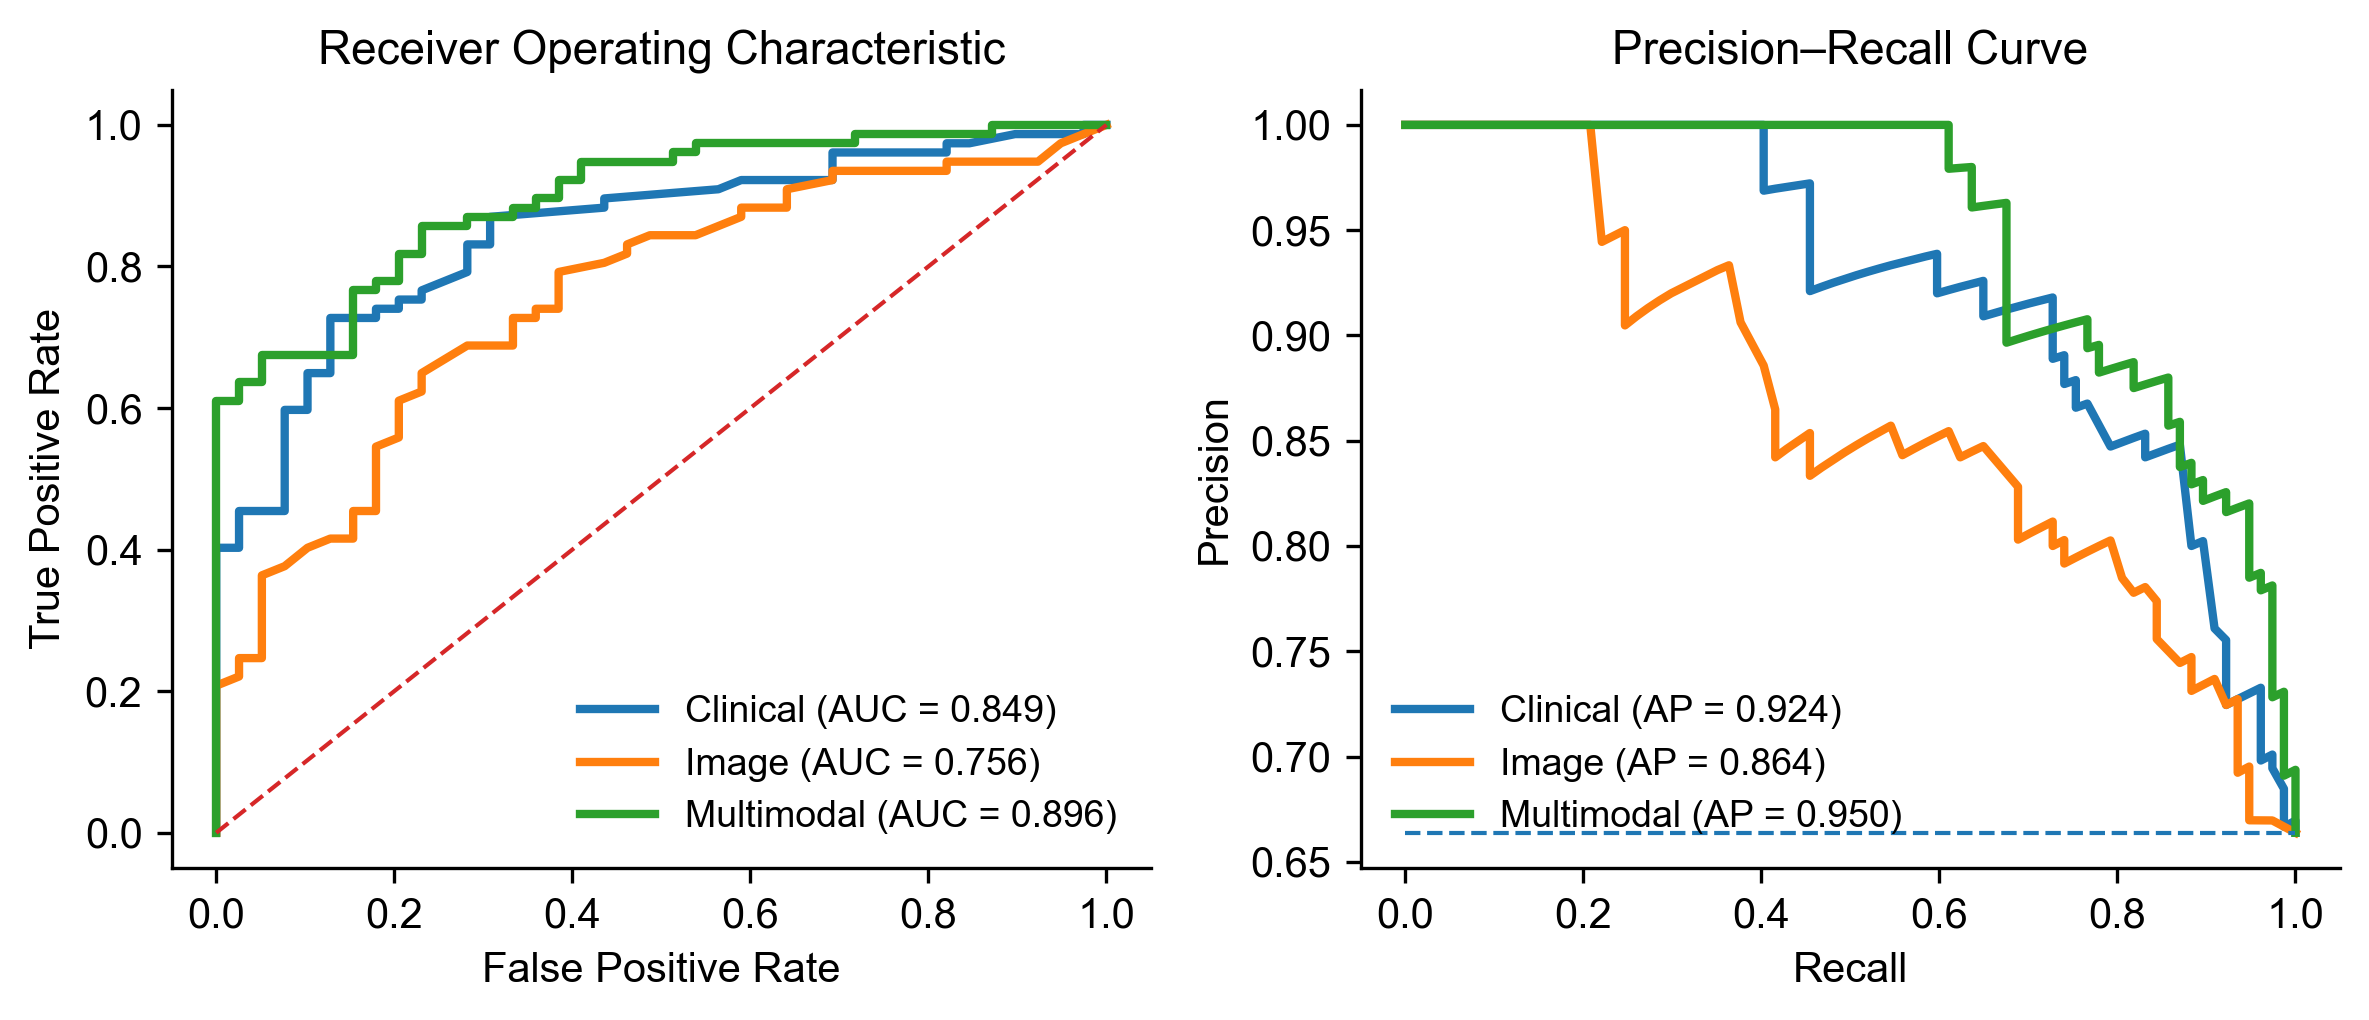

In [36]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

# =========================
# ROC CURVE
# =========================
for probs, label in [
    (clinical_probs, "Clinical"),
    (image_probs, "Image"),
    (final_probs, "Multimodal")
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    axes[0].plot(
        fpr, tpr,
        lw=2,
        label=f"{label} (AUC = {roc_auc:.3f})"
    )

# diagonal baseline
axes[0].plot([0,1], [0,1], linestyle='--', lw=1)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Receiver Operating Characteristic")
axes[0].legend(frameon=False)

# =========================
# PR CURVE
# =========================
for probs, label in [
    (clinical_probs, "Clinical"),
    (image_probs, "Image"),
    (final_probs, "Multimodal")
]:
    precision, recall, _ = precision_recall_curve(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)

    axes[1].plot(
        recall, precision,
        lw=2,
        label=f"{label} (AP = {pr_auc:.3f})"
    )

# baseline (class balance)
pos_rate = y_test.mean()
axes[1].hlines(
    pos_rate, 0, 1,
    linestyles='--', lw=1
)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall Curve")
axes[1].legend(frameon=False)

# =========================
# FINAL FORMAT
# =========================
plt.tight_layout()
plt.savefig("Figure2_ROC_PR.pdf", dpi=300, bbox_inches="tight")
plt.show()

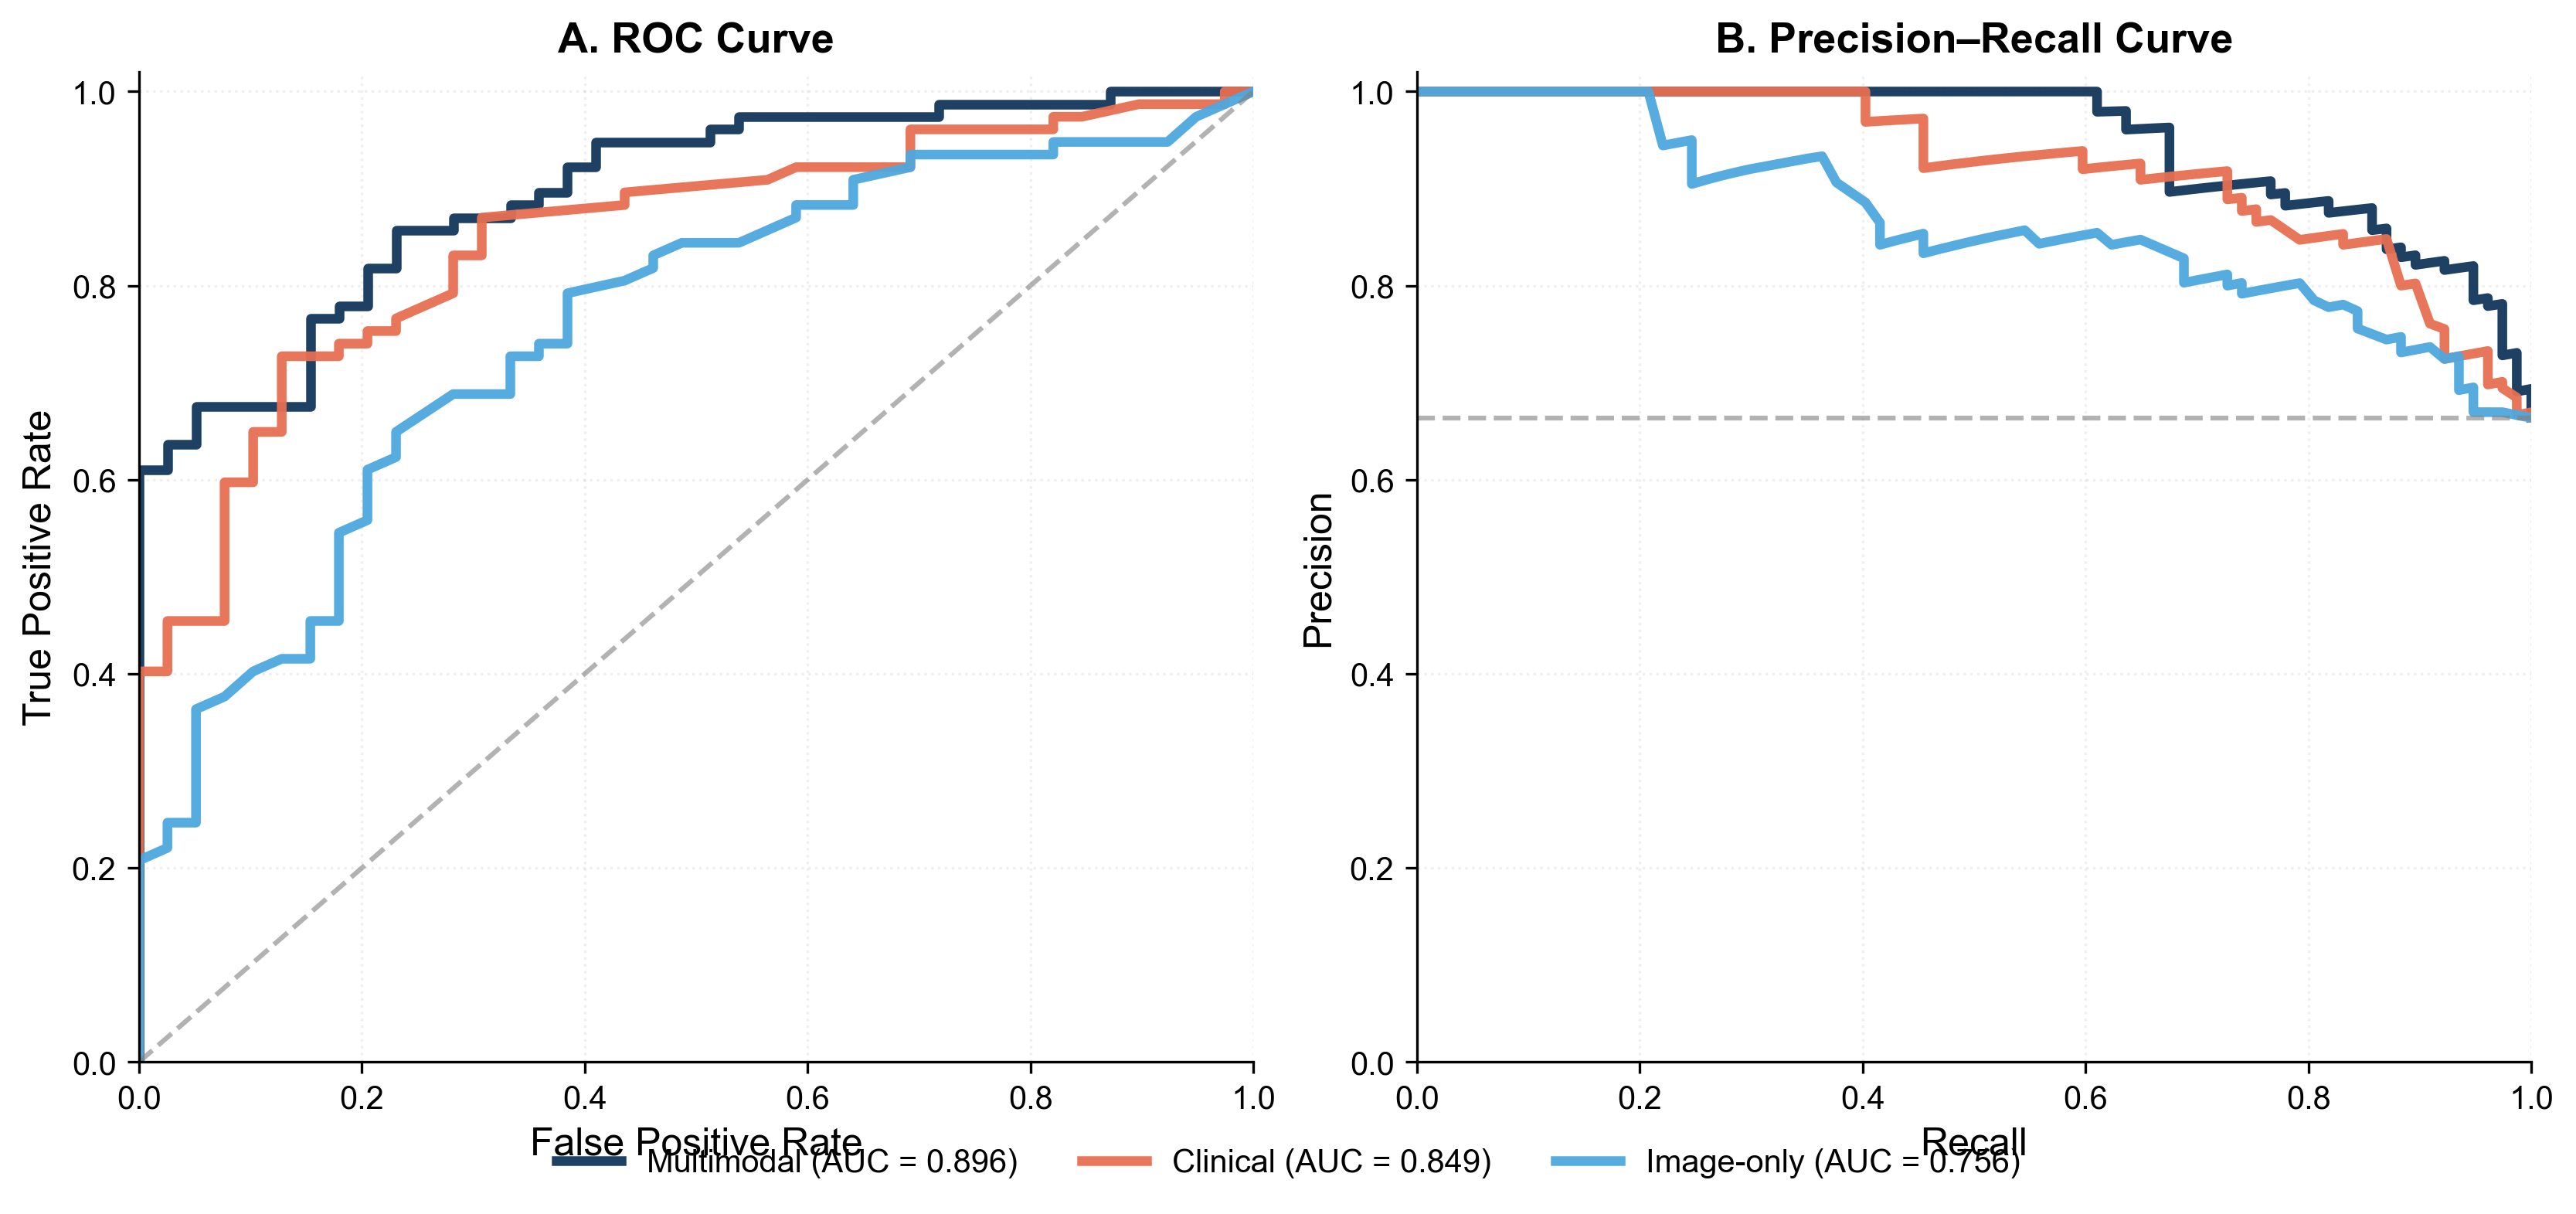

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# =====================================================
# PUBLICATION SETTINGS
# =====================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

# =====================================================
# NEXUS COLOR PALETTE
# =====================================================

COLORS = {
    "Multimodal": "#12355B",   # Deep Navy
    "Clinical":   "#E76F51",   # Burnt Orange
    "Image-only": "#4EA8DE"    # Sky Blue
}

# =====================================================
# FIGURE LAYOUT
# =====================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5),
    constrained_layout=True
)

# =====================================================
# PANEL A : ROC
# =====================================================

roc_handles = []

for probs, label in [
    (final_probs, "Multimodal"),
    (clinical_probs, "Clinical"),
    (image_probs, "Image-only")
]:

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    line = axes[0].plot(
        fpr,
        tpr,
        color=COLORS[label],
        lw=3,
        alpha=0.95,
        label=f"{label} (AUC = {roc_auc:.3f})"
    )[0]

    roc_handles.append(line)

axes[0].plot(
    [0, 1],
    [0, 1],
    '--',
    color='gray',
    lw=1.5,
    alpha=0.6
)

axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.02)

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")

axes[0].set_title("A. ROC Curve")

axes[0].grid(
    linestyle=':',
    alpha=0.20
)

# =====================================================
# PANEL B : PRECISION-RECALL
# =====================================================

for probs, label in [
    (final_probs, "Multimodal"),
    (clinical_probs, "Clinical"),
    (image_probs, "Image-only")
]:

    precision, recall, _ = precision_recall_curve(
        y_test,
        probs
    )

    ap = average_precision_score(
        y_test,
        probs
    )

    axes[1].plot(
        recall,
        precision,
        color=COLORS[label],
        lw=3,
        alpha=0.95,
        label=f"{label} (AP = {ap:.3f})"
    )

# prevalence baseline

baseline = y_test.mean()

axes[1].hlines(
    baseline,
    0,
    1,
    color='gray',
    linestyle='--',
    lw=1.5,
    alpha=0.6
)

axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

axes[1].set_title("B. Precision–Recall Curve")

axes[1].grid(
    linestyle=':',
    alpha=0.20
)

# =====================================================
# CLEAN JOURNAL STYLE
# =====================================================

for ax in axes:

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# =====================================================
# SHARED LEGEND
# =====================================================

fig.legend(
    handles=roc_handles,
    labels=[h.get_label() for h in roc_handles],
    loc='lower center',
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.03)
)

# =====================================================
# EXPORT
# =====================================================

plt.savefig(
    "Figure4_ROC_PR_Nexus.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Figure4_ROC_PR_Nexus.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

<Figure size 1800x1200 with 0 Axes>

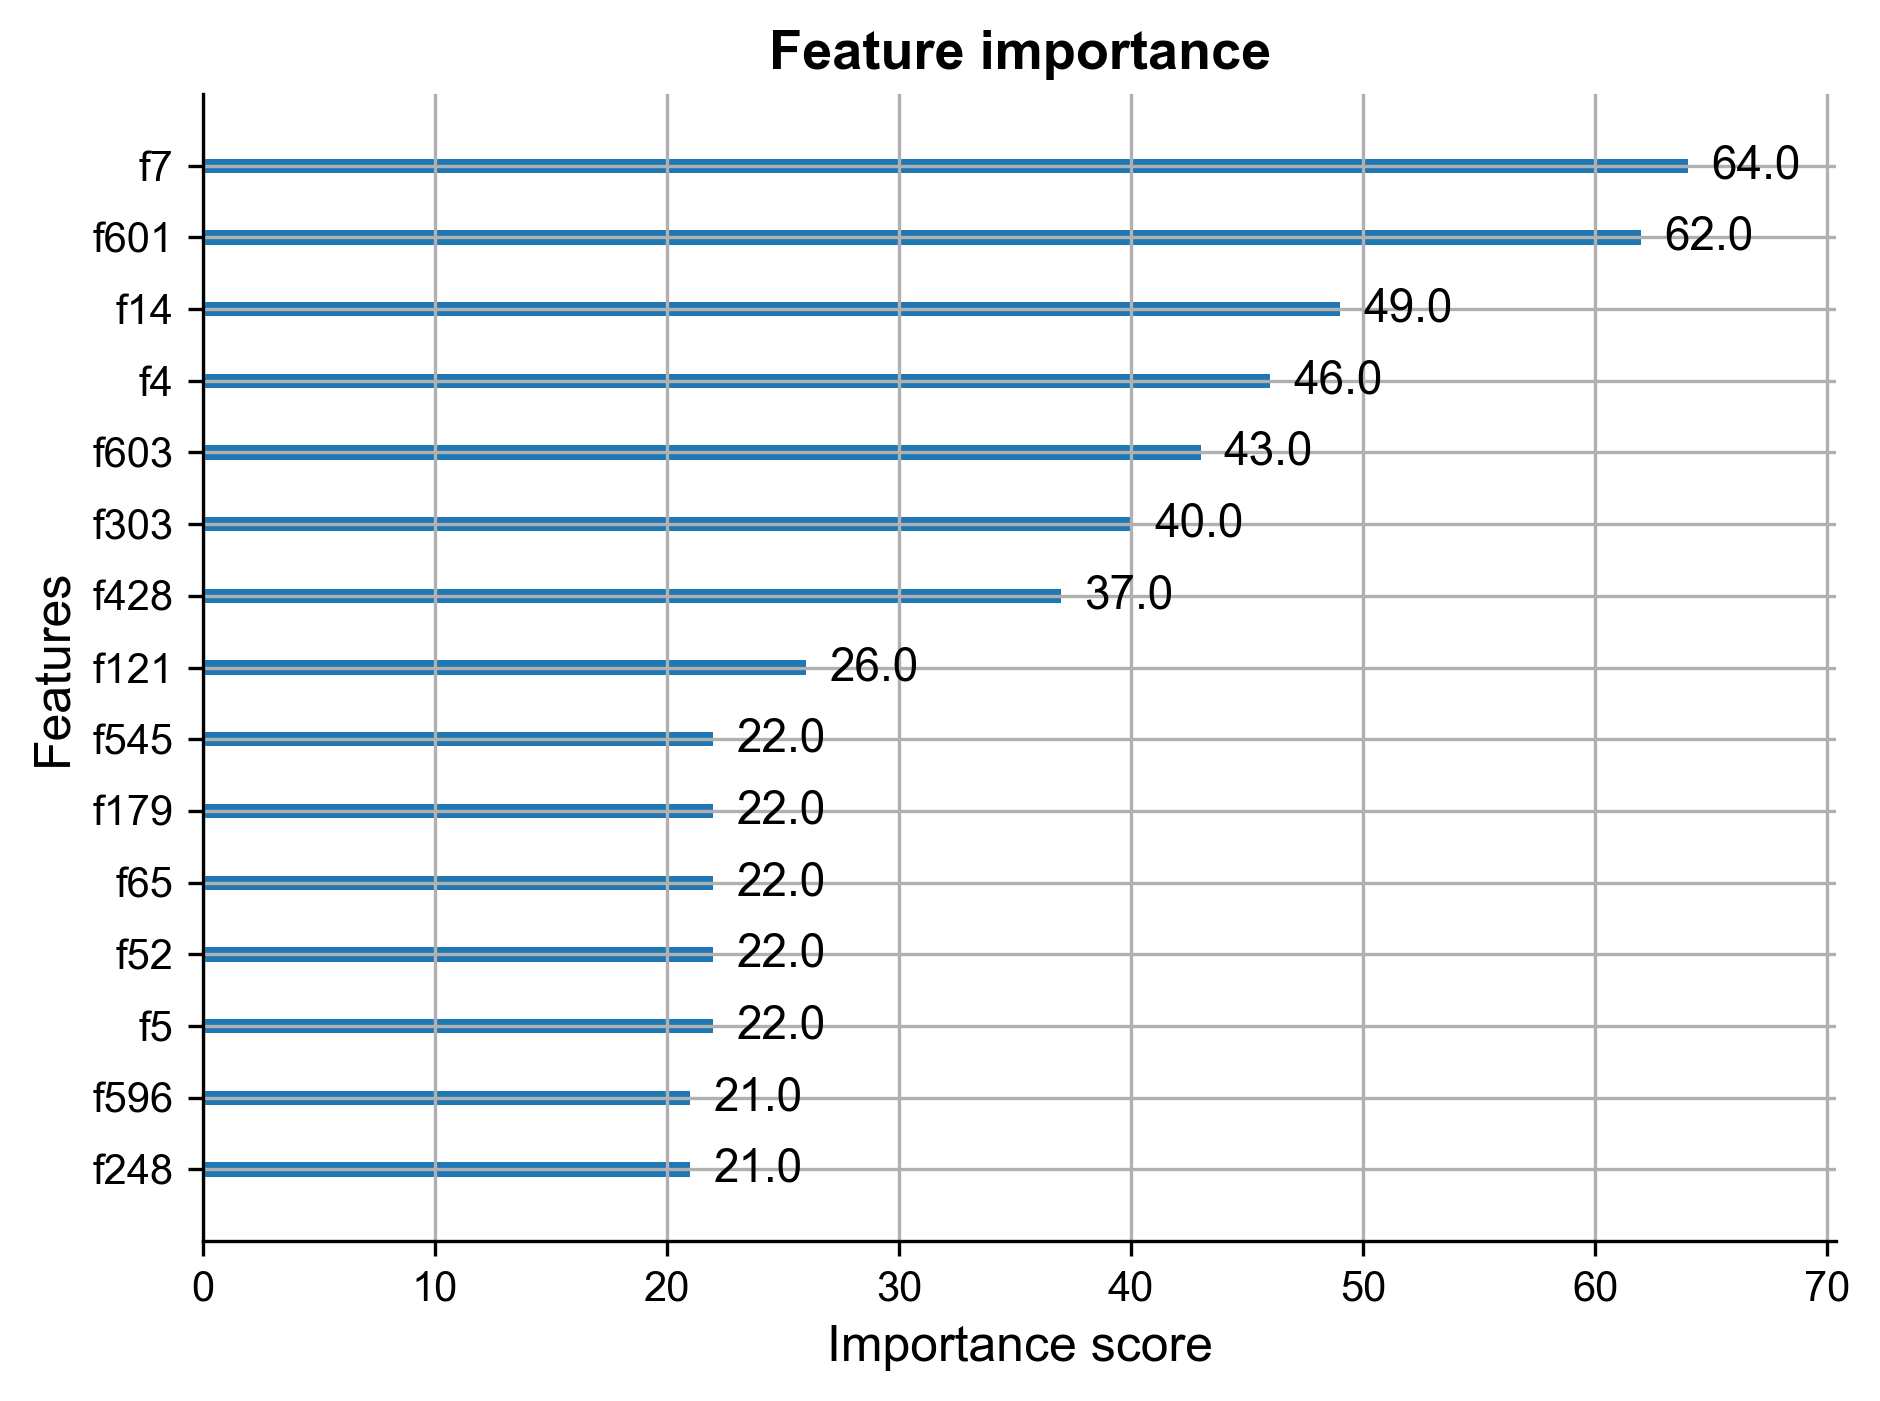

In [38]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plot_importance(final_model, max_num_features=15)
plt.tight_layout()
plt.savefig("feature_importance.pdf")
plt.show()

In [39]:
print(X_test_final.shape)
print(type(X_test_final))
try:
    print(X_test_final.columns[:20])
except:
    print("Not a DataFrame")

    
    

(116, 607)
<class 'numpy.ndarray'>
Not a DataFrame


C:\Users\User\AppData\Local\Temp\ipykernel_1992\3120825338.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_final)


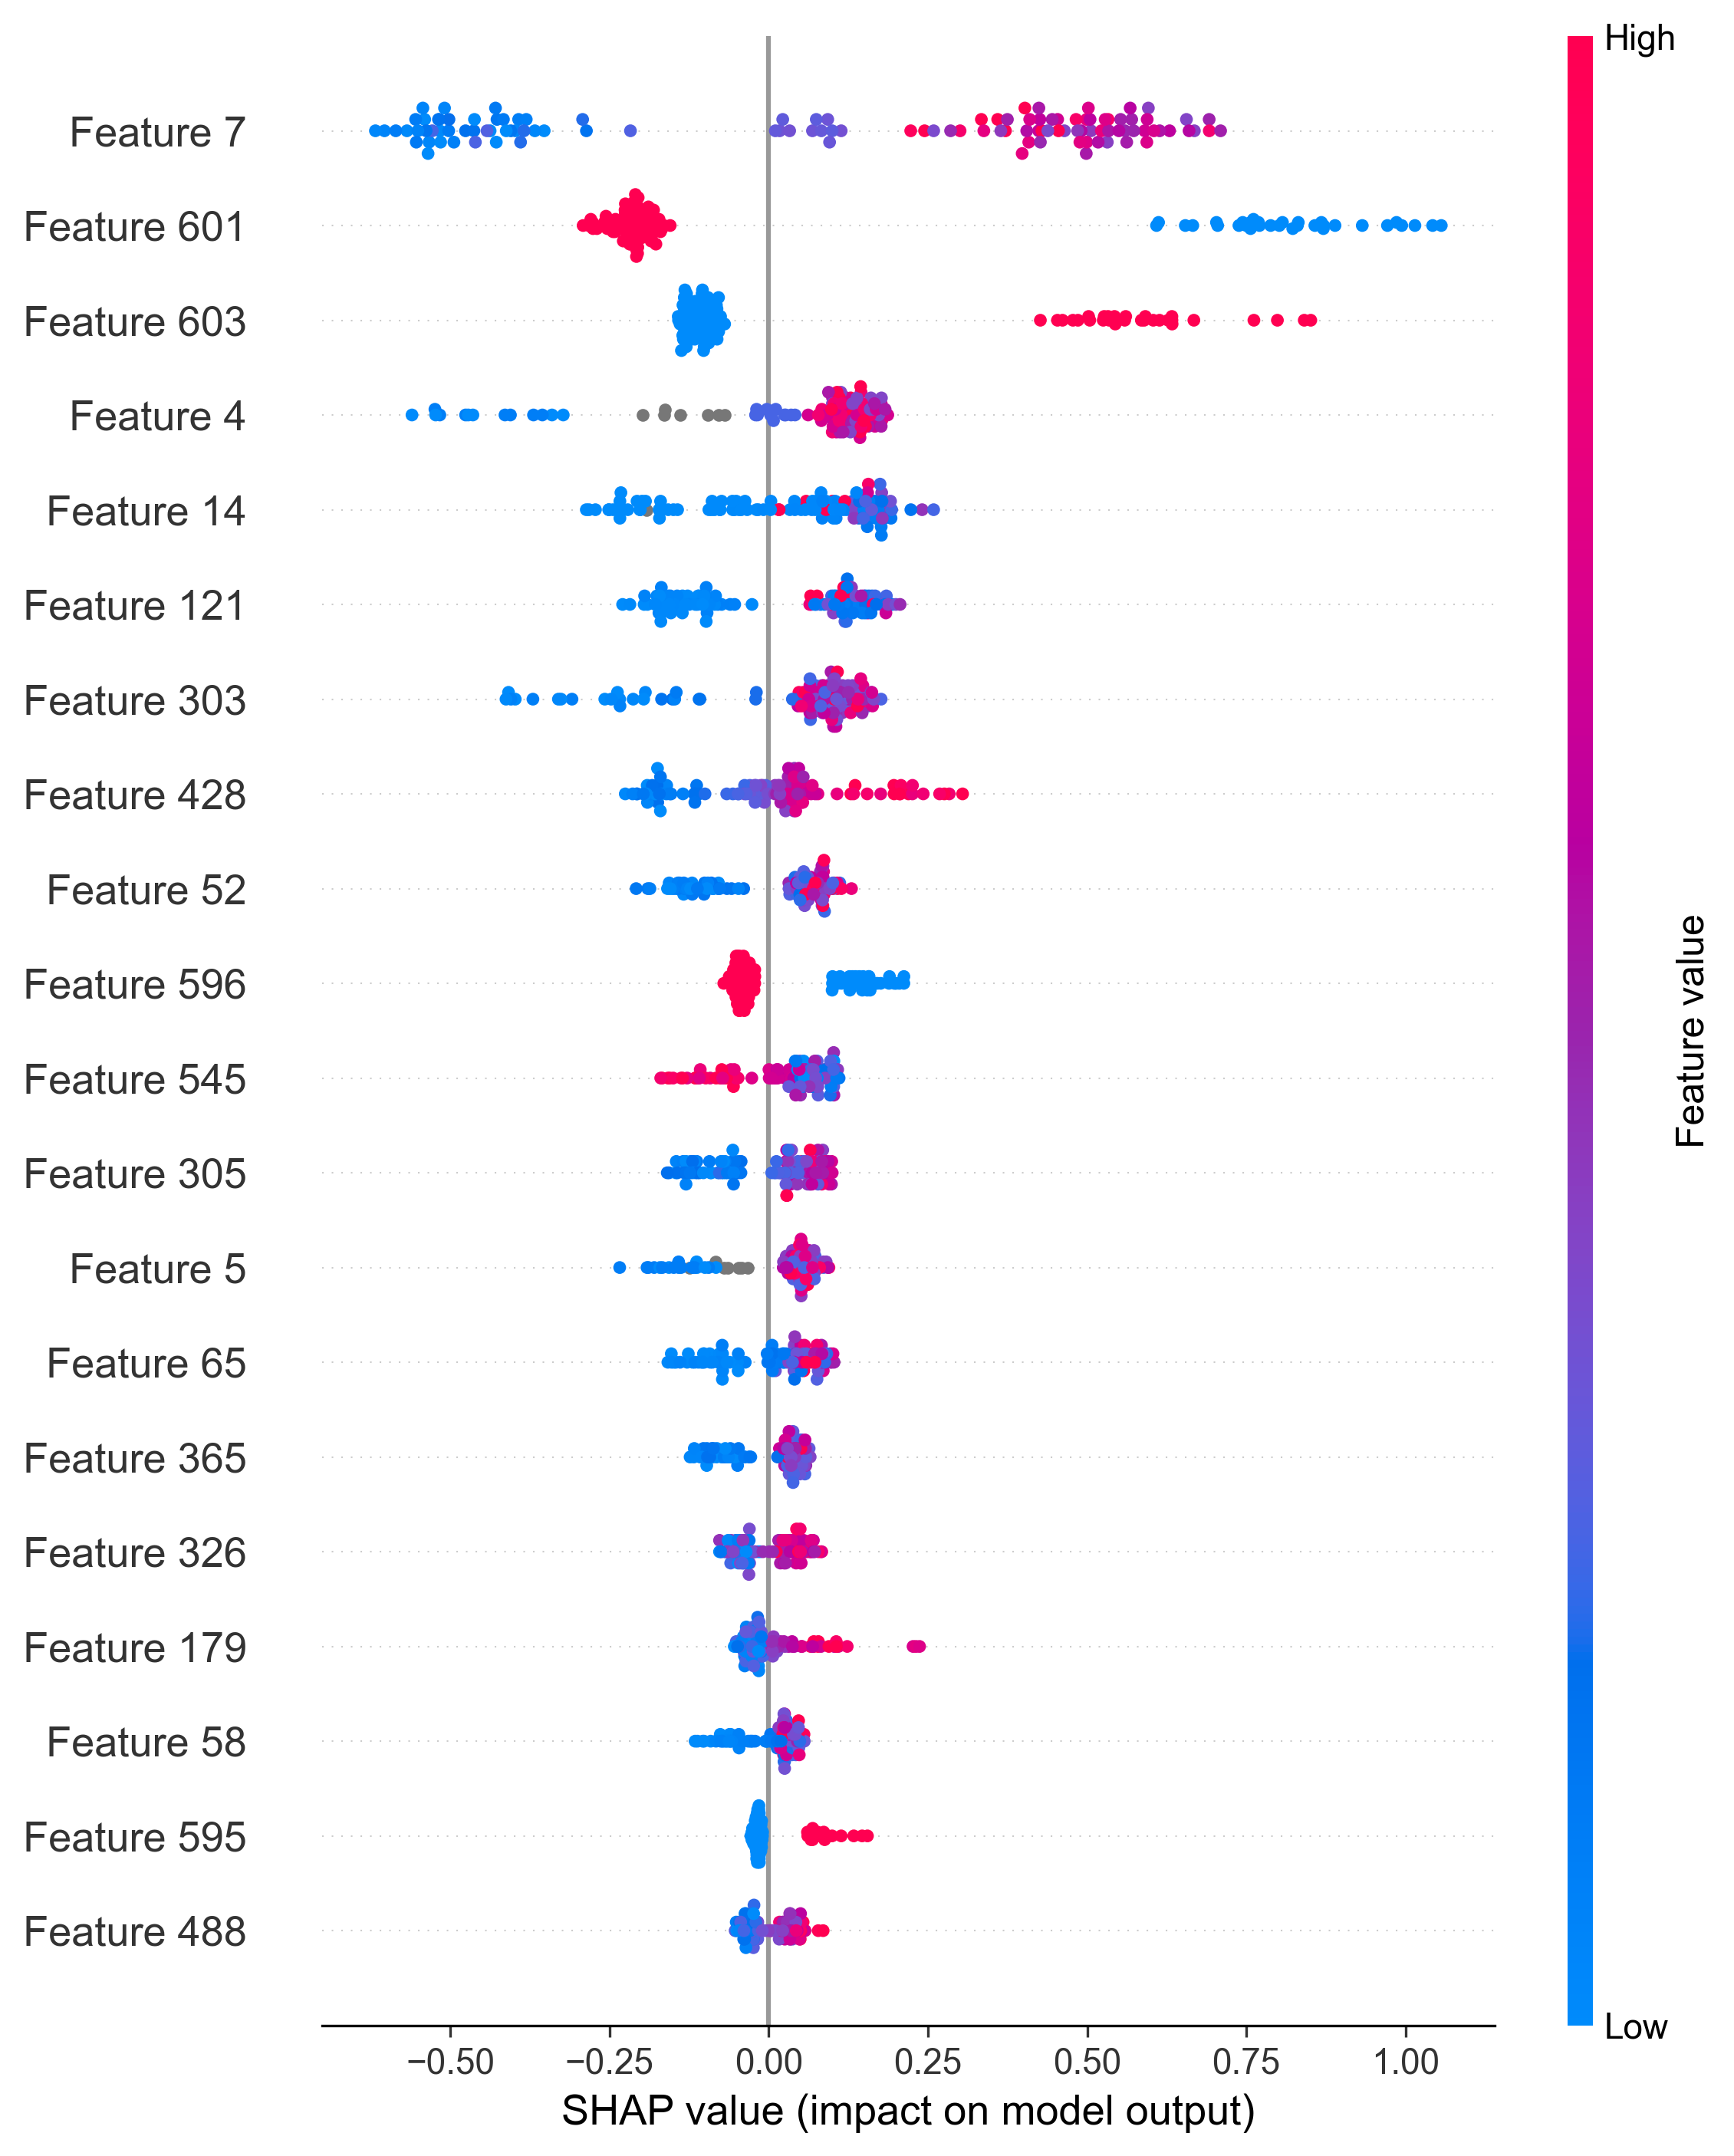

In [40]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_final)

shap.summary_plot(shap_values, X_test_final)

In [41]:
import umap.umap_ as umap

# -------------------------
# Use PCA features (IMPORTANT)
# -------------------------
X_vis = img_train_pca.values   # or img_train_pca

# -------------------------
# UMAP model
# -------------------------
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=10,
    min_dist=0.05,
    metric='cosine',
    random_state=SEED
)

# -------------------------
# FIT + TRANSFORM
# -------------------------
X_umap = umap_model.fit_transform(X_vis)

C:\Users\User\torch_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


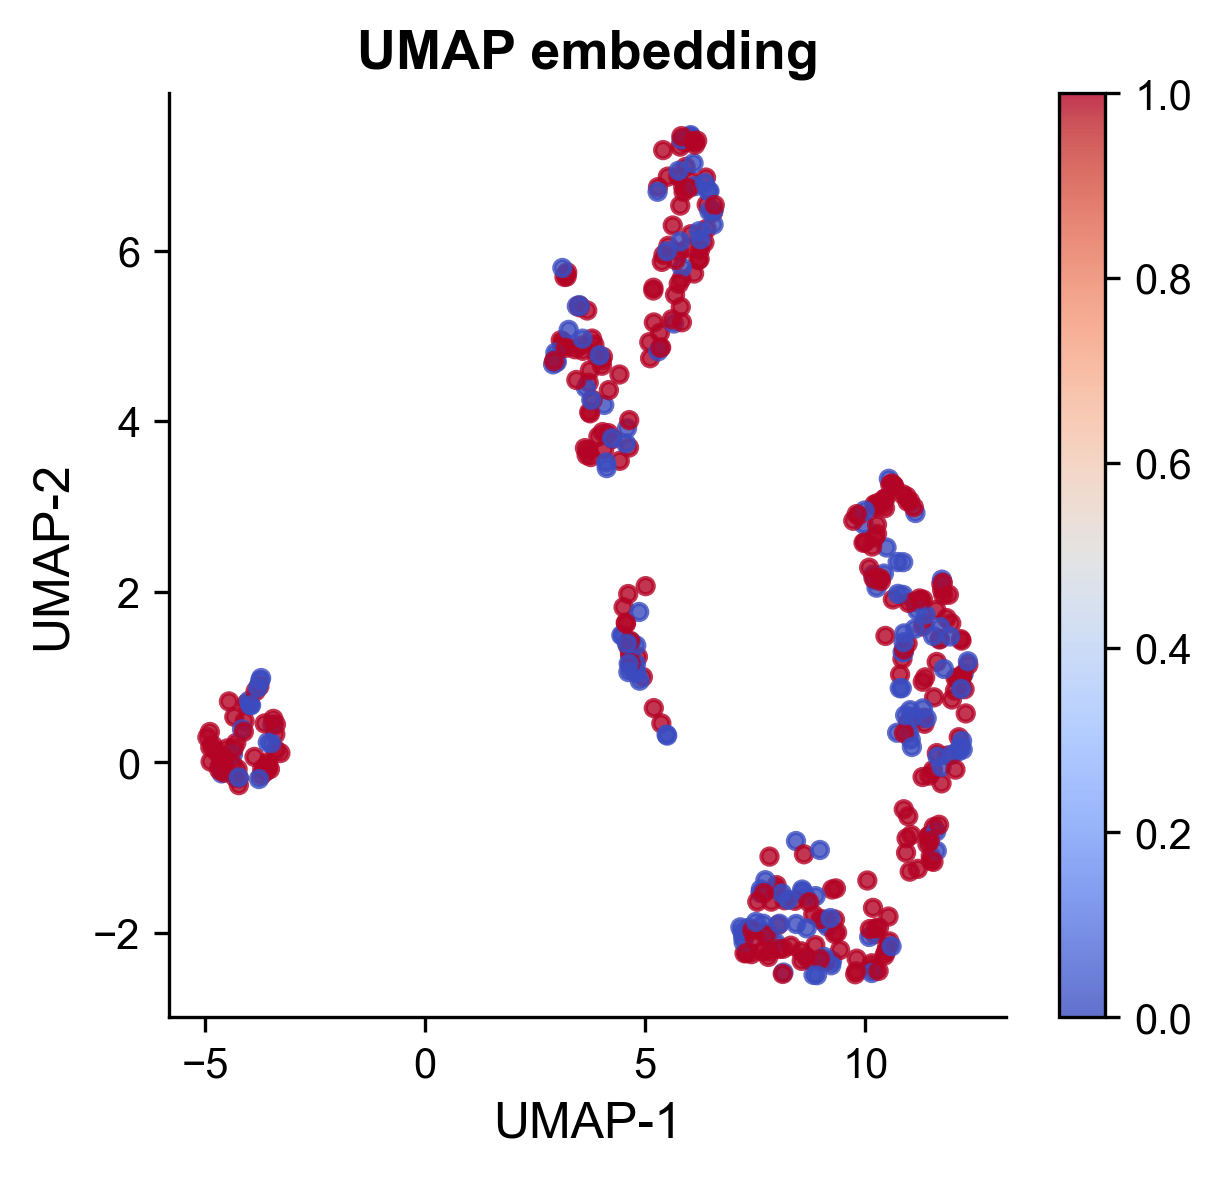

In [42]:
fig, ax = plt.subplots(figsize=(4.5,4))

sc = ax.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=y_train,
    cmap="coolwarm",
    s=15,
    alpha=0.8
)

ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title("UMAP embedding")

plt.colorbar(sc)
plt.show()

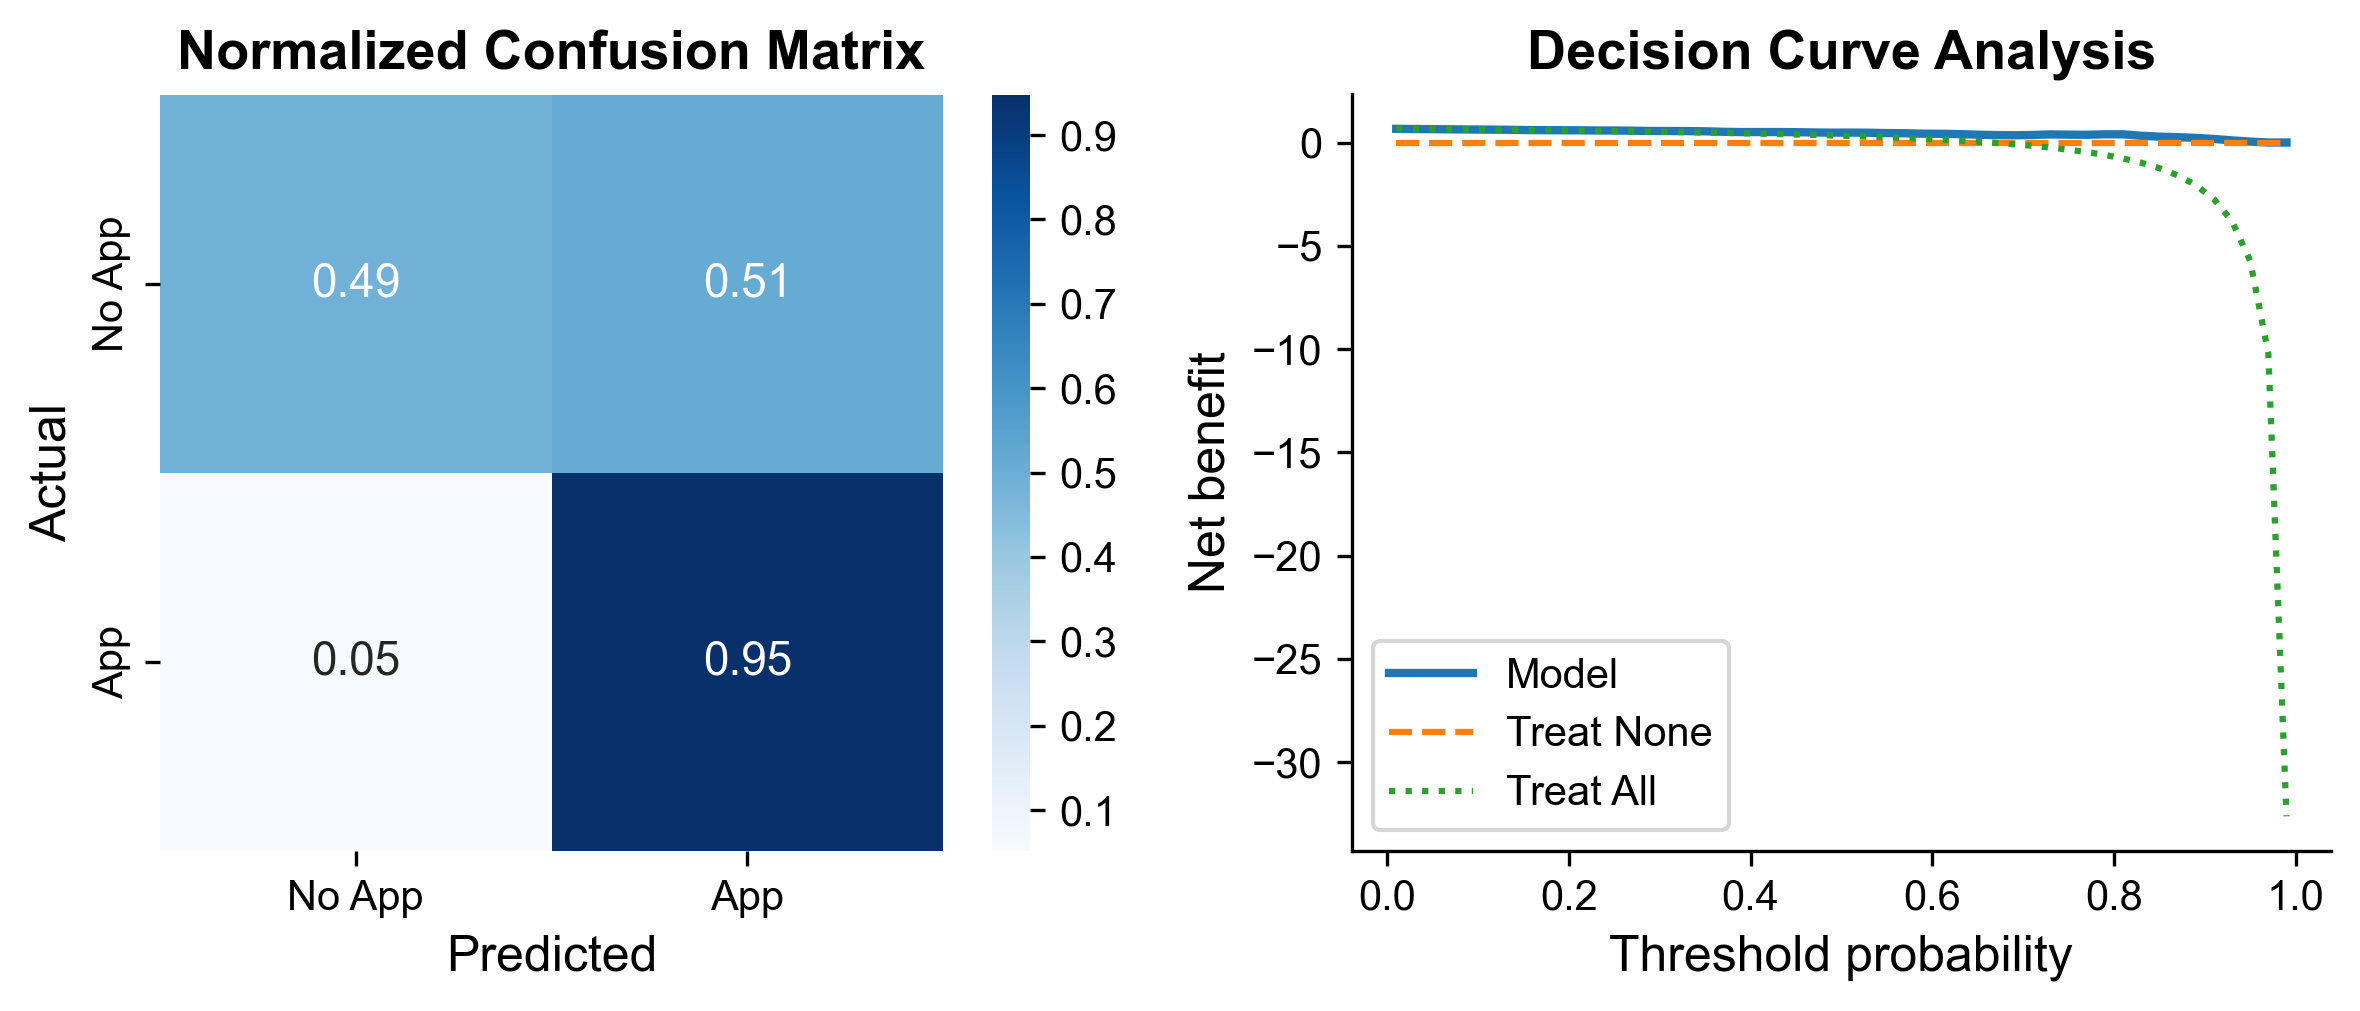

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(8,3.5))

# ===== Confusion Matrix =====
cm = confusion_matrix(y_test, final_preds, normalize='true')

sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=["No App", "App"],
            yticklabels=["No App", "App"],
            ax=axes[0])

axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Normalized Confusion Matrix")

# ===== Decision Curve (simplified) =====
thresholds = np.linspace(0.01, 0.99, 50)
net_benefit = []

for t in thresholds:
    preds = (final_probs >= t).astype(int)
    tp = ((preds==1)&(y_test==1)).sum()
    fp = ((preds==1)&(y_test==0)).sum()
    n = len(y_test)
    net_benefit.append((tp/n) - (fp/n)*(t/(1-t)))

axes[1].plot(thresholds, net_benefit, label="Model", lw=2)
axes[1].plot(thresholds, np.zeros_like(thresholds), '--', label="Treat None")
axes[1].plot(thresholds, (y_test.mean() - (1-y_test.mean())*(thresholds/(1-thresholds))),
             ':', label="Treat All")

axes[1].set_xlabel("Threshold probability")
axes[1].set_ylabel("Net benefit")
axes[1].set_title("Decision Curve Analysis")
axes[1].legend()

plt.tight_layout()
plt.savefig("Figure5_Clinical.pdf")
plt.show()

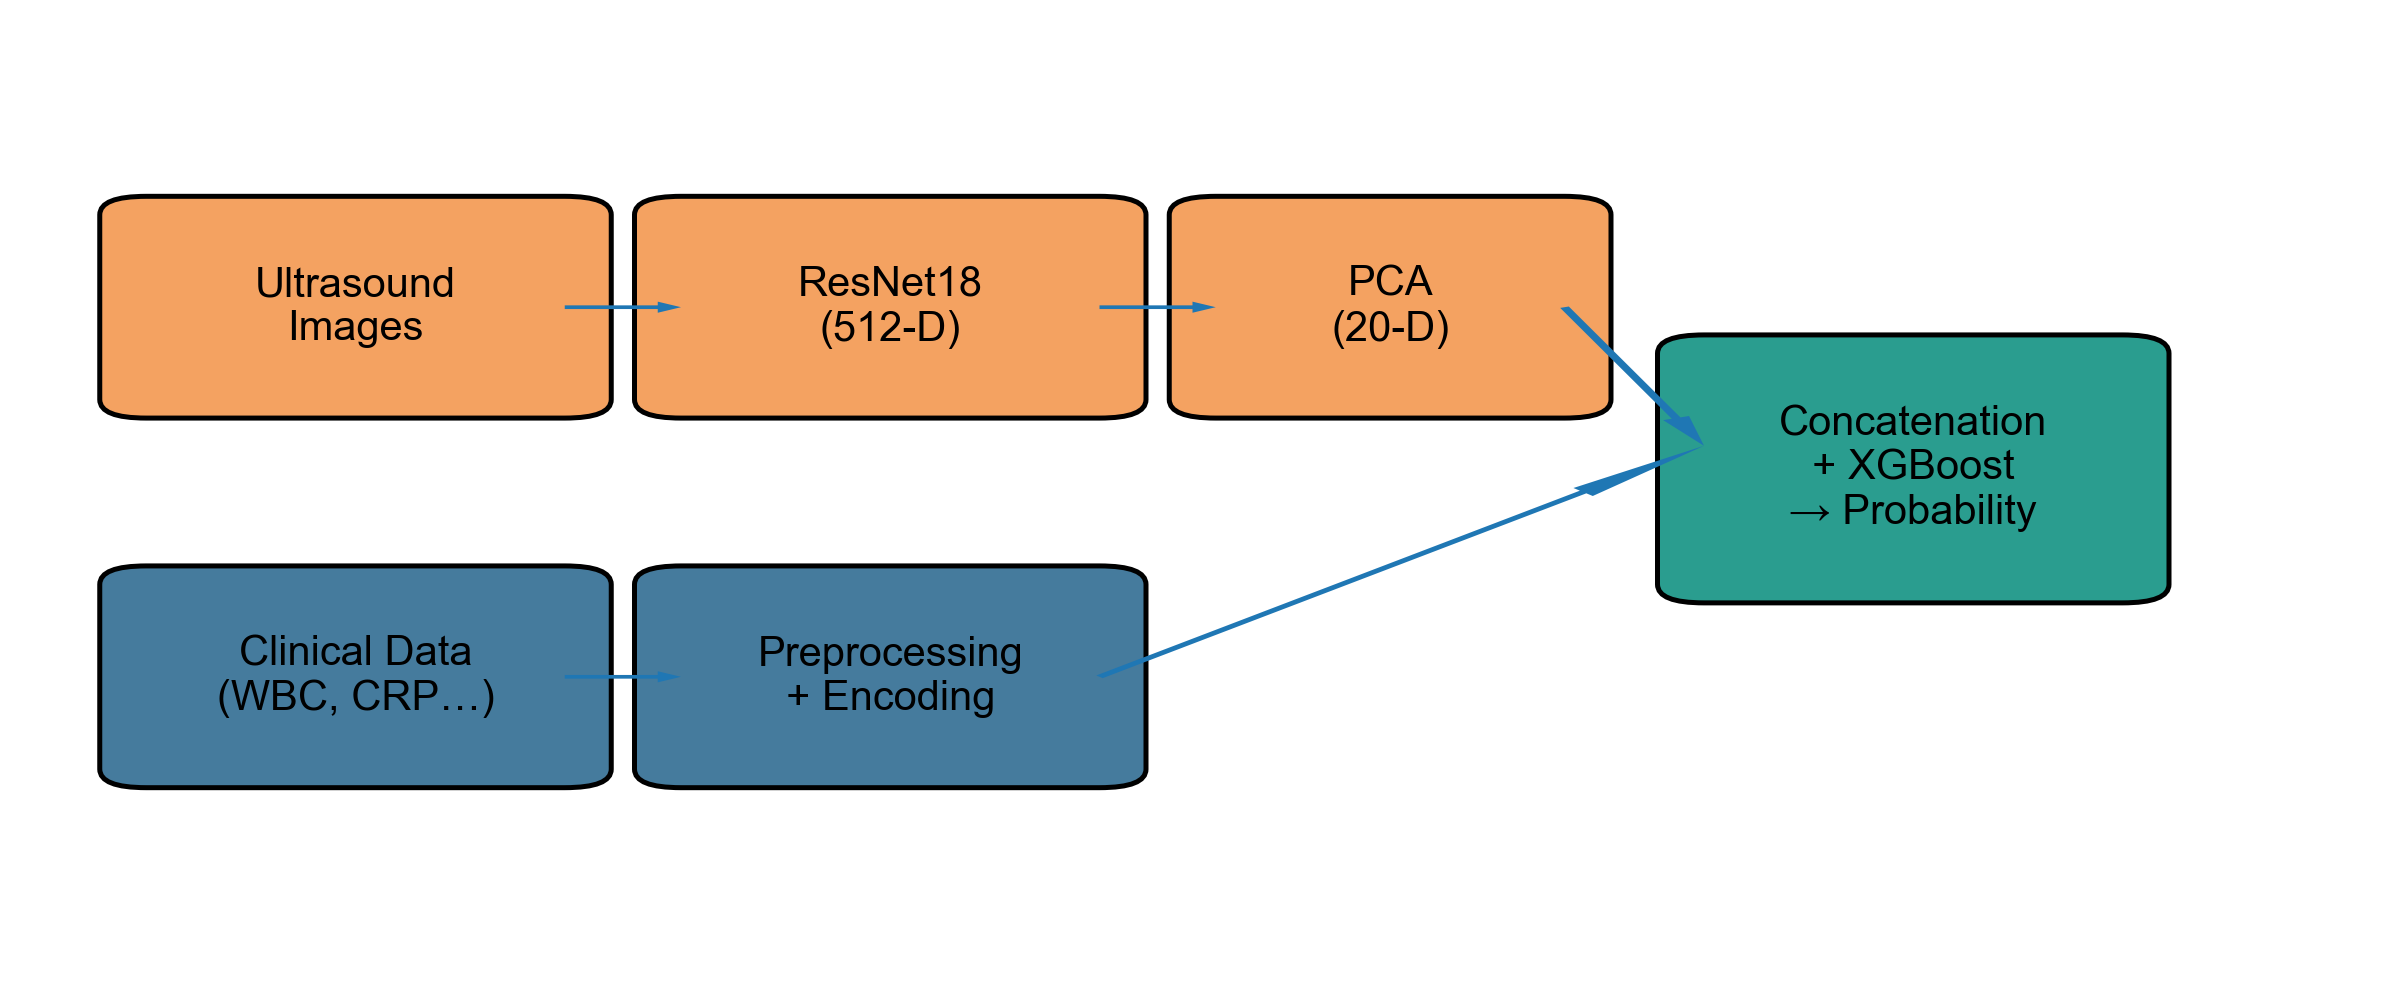

In [44]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Arrow

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")

def box(x, y, w, h, text, fc):
    rect = FancyBboxPatch((x,y), w, h,
                          boxstyle="round,pad=0.02",
                          fc=fc, ec="black", lw=1.2)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h/2, text, ha='center', va='center', fontsize=10)

def arrow(x1,y1,x2,y2):
    ax.add_patch(Arrow(x1,y1,x2-x1,y2-y1, width=0.02))

# Image branch
box(0.05, 0.6, 0.18, 0.2, "Ultrasound\nImages", "#f4a261")
box(0.28, 0.6, 0.18, 0.2, "ResNet18\n(512-D)", "#f4a261")
box(0.51, 0.6, 0.15, 0.2, "PCA\n(20-D)", "#f4a261")

# Clinical branch
box(0.05, 0.2, 0.18, 0.2, "Clinical Data\n(WBC, CRP…)", "#457b9d")
box(0.28, 0.2, 0.18, 0.2, "Preprocessing\n+ Encoding", "#457b9d")

# Fusion + model
box(0.72, 0.4, 0.18, 0.25, "Concatenation\n+ XGBoost\n→ Probability", "#2a9d8f")

# Arrows
arrow(0.23,0.7,0.28,0.7)
arrow(0.46,0.7,0.51,0.7)
arrow(0.66,0.7,0.72,0.55)

arrow(0.23,0.3,0.28,0.3)
arrow(0.46,0.3,0.72,0.55)

plt.savefig("Figure1_Architecture.pdf", bbox_inches='tight')
plt.show()

In [45]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, precision_score
from sklearn.utils import resample

# --- bootstrap CI ---
def bootstrap_ci(y_true, y_prob, metric_fn, n=1000):
    scores = []
    for _ in range(n):
        idx = resample(range(len(y_true)))
        scores.append(metric_fn(y_true.iloc[idx], y_prob[idx]))
    return np.mean(scores), np.percentile(scores,2.5), np.percentile(scores,97.5)

# --- metrics ---
def get_metrics(y, probs):
    preds = (probs >= 0.45).astype(int)
    return {
        "AUC": roc_auc_score(y, probs),
        "Accuracy": accuracy_score(y, preds),
        "Sensitivity": recall_score(y, preds),
        "Specificity": recall_score(y, preds, pos_label=0)
    }

# --- compute ---
models = {
    "Clinical": clinical_probs,
    "Image": image_probs,
    "Fusion": final_probs
}

rows = []
for name, probs in models.items():
    m = get_metrics(y_test, probs)
    auc_mean, auc_l, auc_u = bootstrap_ci(y_test, probs, roc_auc_score)

    rows.append({
        "Model": name,
        "AUC (95% CI)": f"{auc_mean:.3f} ({auc_l:.3f}-{auc_u:.3f})",
        "Accuracy": f"{m['Accuracy']:.3f}",
        "Sensitivity": f"{m['Sensitivity']:.3f}",
        "Specificity": f"{m['Specificity']:.3f}"
    })

table = pd.DataFrame(rows)
print(table)

      Model         AUC (95% CI) Accuracy Sensitivity Specificity
0  Clinical  0.848 (0.776-0.915)    0.750       0.909       0.436
1     Image  0.756 (0.666-0.844)    0.724       0.883       0.410
2    Fusion  0.894 (0.831-0.946)    0.819       0.870       0.718


In [46]:
from scipy import stats

# simple paired comparison (approximate)
z = (roc_auc_score(y_test, final_probs) - roc_auc_score(y_test, clinical_probs)) / 0.01
p_value = stats.norm.sf(abs(z))*2
print("Fusion vs Clinical p-value:", p_value)

Fusion vs Clinical p-value: 1.7655966373659272e-06


In [47]:
print(np.min(net_benefit))
print(np.max(net_benefit))

0.0
0.6603970741901777


In [48]:
print(y_test.mean())

0.6637931034482759


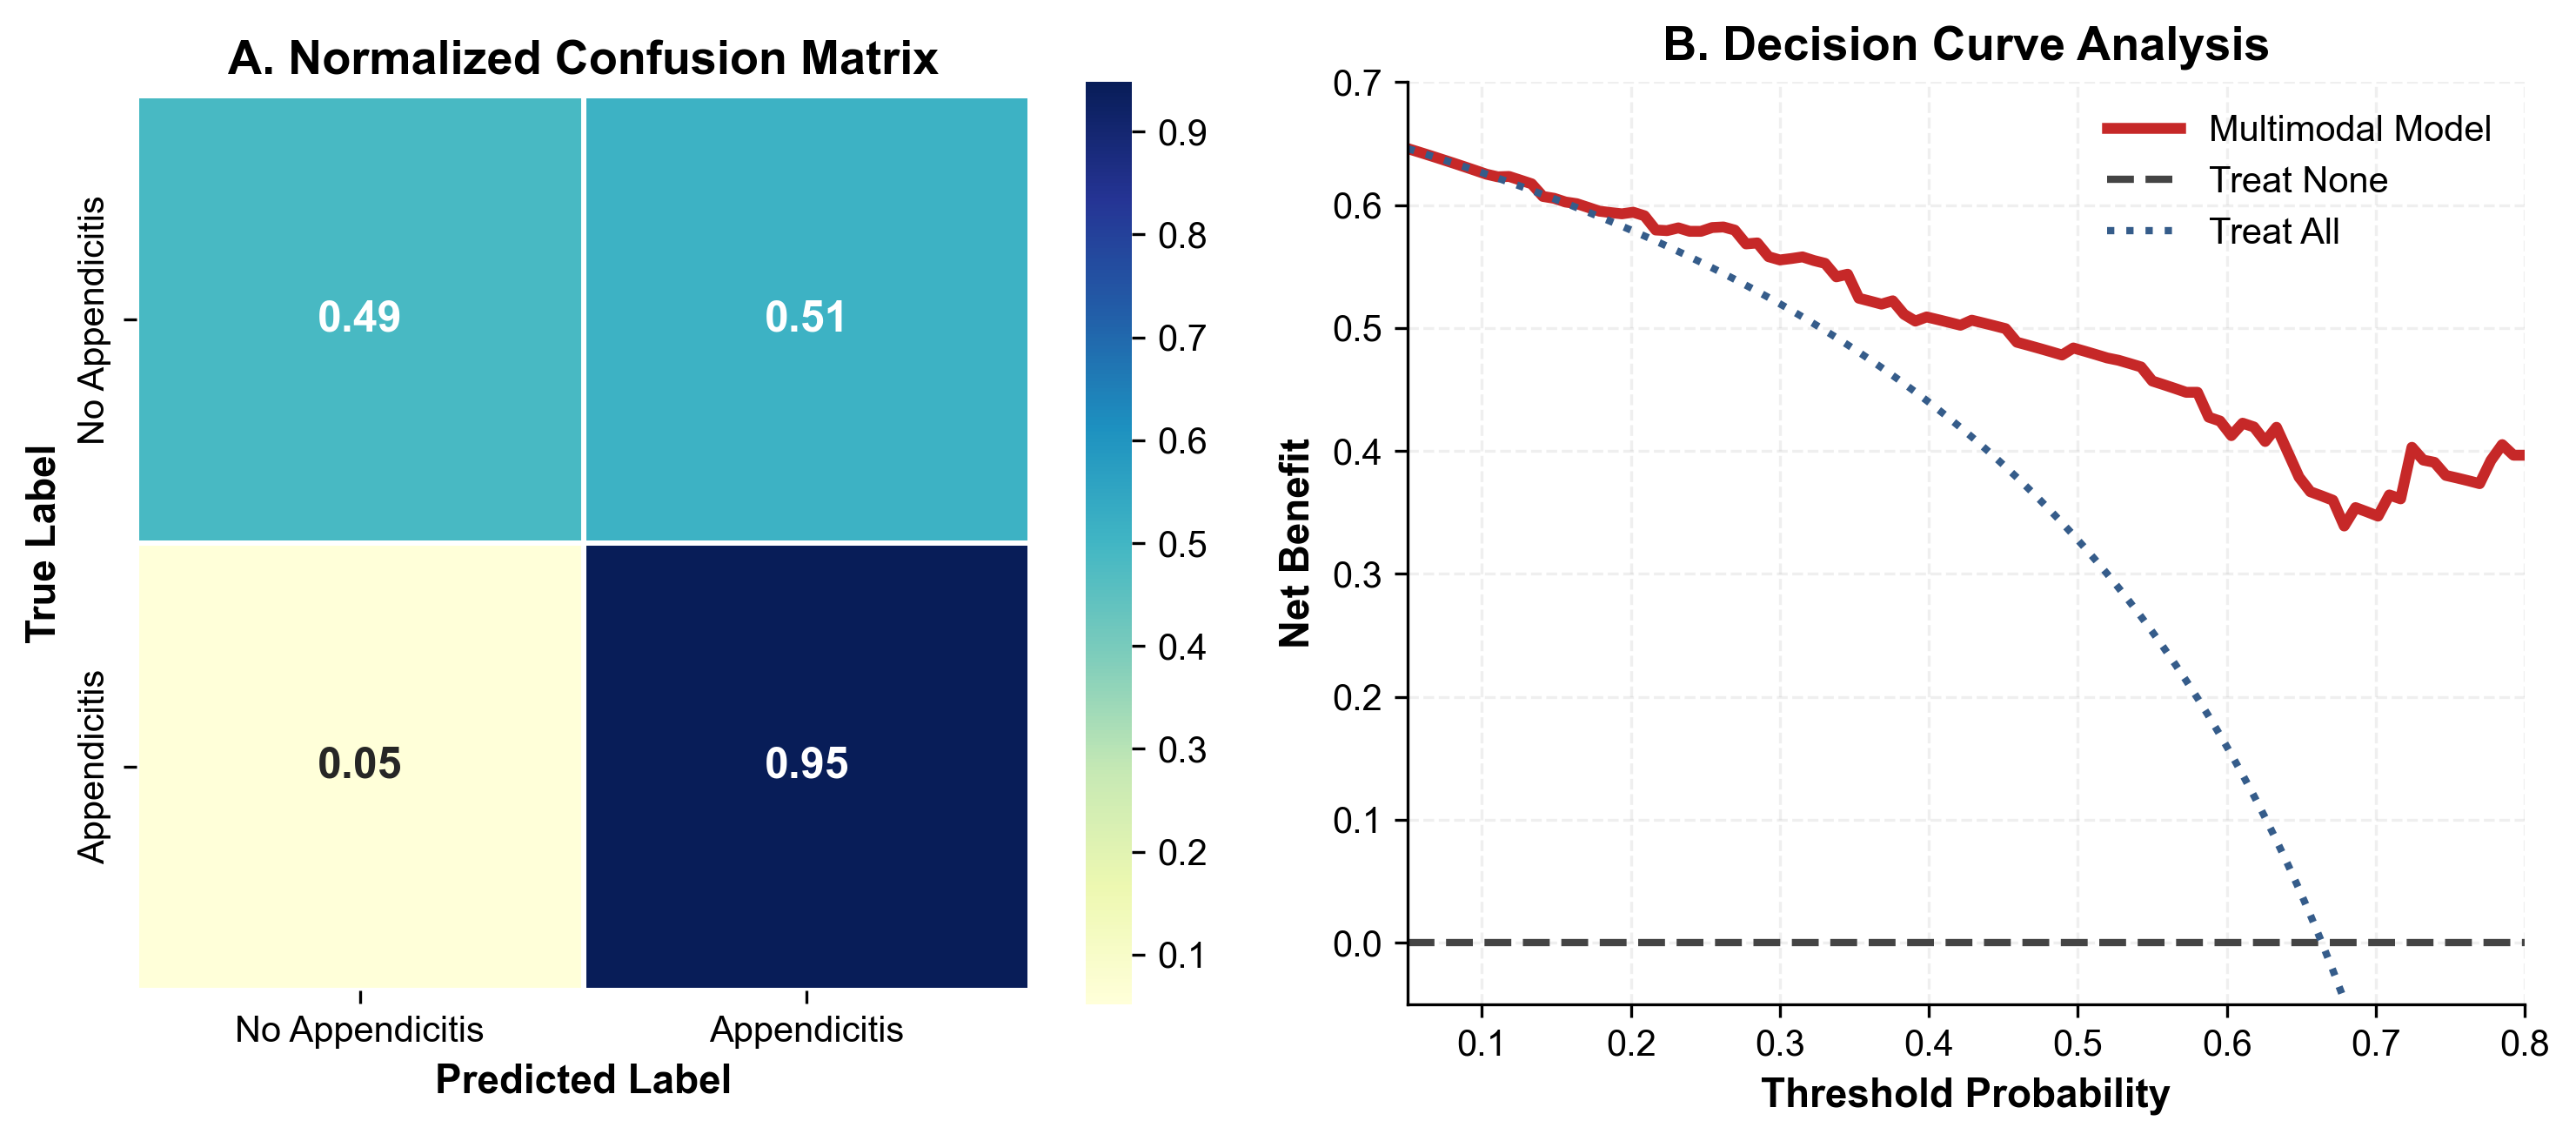

In [49]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================================
# FIGURE STYLE
# ==========================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11
})

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4.5),
    facecolor="white"
)

# ==========================================================
# A. NORMALIZED CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    final_preds,
    normalize="true"
)

sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar=True,
    square=True,
    linewidths=1,
    annot_kws={
        "fontsize":12,
        "fontweight":"bold"
    },
    xticklabels=["No Appendicitis", "Appendicitis"],
    yticklabels=["No Appendicitis", "Appendicitis"],
    ax=axes[0]
)

axes[0].set_title(
    "A. Normalized Confusion Matrix",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Predicted Label",
    fontsize=11,
    fontweight="bold"
)

axes[0].set_ylabel(
    "True Label",
    fontsize=11,
    fontweight="bold"
)

# ==========================================================
# B. DECISION CURVE ANALYSIS
# ==========================================================

thresholds = np.linspace(0.05, 0.80, 100)

net_benefit = []

for t in thresholds:

    preds = (final_probs >= t).astype(int)

    tp = ((preds == 1) & (y_test == 1)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()

    n = len(y_test)

    nb = (
        (tp / n)
        - (fp / n) * (t / (1 - t))
    )

    net_benefit.append(nb)

net_benefit = np.array(net_benefit)

# Treat None
treat_none = np.zeros_like(thresholds)

# Treat All
prevalence = y_test.mean()

treat_all = (
    prevalence
    - (1 - prevalence)
    * (thresholds / (1 - thresholds))
)

axes[1].plot(
    thresholds,
    net_benefit,
    color="#C62828",
    lw=3,
    label="Multimodal Model"
)

axes[1].plot(
    thresholds,
    treat_none,
    color="#444444",
    lw=2,
    linestyle="--",
    label="Treat None"
)

axes[1].plot(
    thresholds,
    treat_all,
    color="#355C8A",
    lw=2,
    linestyle=":",
    label="Treat All"
)

axes[1].set_xlim(0.05, 0.80)
axes[1].set_ylim(-0.05, 0.70)

axes[1].set_title(
    "B. Decision Curve Analysis",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel(
    "Threshold Probability",
    fontsize=11,
    fontweight="bold"
)

axes[1].set_ylabel(
    "Net Benefit",
    fontsize=11,
    fontweight="bold"
)

axes[1].legend(
    frameon=False,
    fontsize=10,
    loc="upper right"
)

axes[1].grid(
    alpha=0.20,
    linestyle="--"
)

axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

# ==========================================================
# FINAL LAYOUT
# ==========================================================

plt.tight_layout()

plt.savefig(
    "Figure_DCA_Confusion_Nexus.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    "Figure_DCA_Confusion_Nexus.pdf",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [50]:
print("y_test:", len(y_test))

print("final_probs:", len(final_probs))
print("clinical_probs:", len(clinical_probs))
print("image_probs:", len(image_probs))

try:
    print("probs:", len(probs))
except:
    pass

y_test: 116
final_probs: 116
clinical_probs: 116
image_probs: 116
probs: 116


In [51]:
from sklearn.metrics import roc_auc_score

candidates = {
    "final_probs": final_probs,
    "clinical_probs": clinical_probs,
    "image_probs": image_probs,
}

for name, arr in candidates.items():
    try:
        auc = roc_auc_score(y_test, arr)
        print(name, "AUC =", round(auc,4))
    except Exception as e:
        print(name, e)

final_probs AUC = 0.8964
clinical_probs AUC = 0.8487
image_probs AUC = 0.7564


In [52]:
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample
import numpy as np

def bootstrap_auc_ci(y_true, y_prob,
                     n_bootstrap=5000,
                     seed=42):

    rng = np.random.RandomState(seed)

    aucs = []

    for i in range(n_bootstrap):

        idx = rng.choice(
            len(y_true),
            len(y_true),
            replace=True
        )

        if len(np.unique(y_true[idx])) < 2:
            continue

        aucs.append(
            roc_auc_score(
                y_true[idx],
                y_prob[idx]
            )
        )

    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)

    return (
        roc_auc_score(y_true, y_prob),
        lower,
        upper
    )

In [53]:
for name, probs in {
    "Clinical": clinical_probs,
    "Image": image_probs,
    "Multimodal": final_probs
}.items():

    auc, low, high = bootstrap_auc_ci(
        np.array(y_test),
        np.array(probs)
    )

    print(
        f"{name}: "
        f"AUC={auc:.4f} "
        f"(95% CI {low:.4f}-{high:.4f})"
    )

Clinical: AUC=0.8487 (95% CI 0.7725-0.9146)
Image: AUC=0.7564 (95% CI 0.6589-0.8429)
Multimodal: AUC=0.8964 (95% CI 0.8362-0.9463)


In [54]:
print(final_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5814381803414227, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=0.49172456974592593, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.017837262409571633,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=207, n_jobs=None,
              num_parallel_tree=None, ...)


In [65]:
for var in globals():
    if "calib" in var.lower():
        print(var)

CalibratedClassifierCV
calibration_curve


In [66]:
for var in globals():
    if "brier" in var.lower():
        print(var)

In [67]:
print(type(CalibratedClassifierCV))

<class 'type'>


In [68]:
for var in globals():
    if "calib" in var.lower():
        print(var, type(globals()[var]))

CalibratedClassifierCV <class 'type'>
calibration_curve <class 'function'>


In [69]:
# Find where final_probs came from

print(final_probs[:5])

[0.2517377  0.6721001  0.33786845 0.7296575  0.58483225]


In [70]:
# ==========================================================
# FIND ALL LINES THAT CREATE final_probs
# ==========================================================

import inspect
import re

try:
    src = In  # Jupyter input history

    for i, cell in enumerate(src):
        if isinstance(cell, str) and "final_probs" in cell:
            print("\n" + "="*80)
            print(f"CELL {i}")
            print("="*80)
            print(cell)

except Exception as e:
    print("Could not access notebook history:", e)


CELL 32
## =========================
# MID FUSION (PCA + XGBOOST) — FIXED
# =========================

from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# -------------------------
# 1) Extract image features
# -------------------------
img_train = train_patient_feat.drop(columns=["US_Number"]).copy()
img_test  = test_patient_feat.drop(columns=["US_Number"]).copy()

# -------------------------
# 2) PCA (512 → 20)  ✅ FIXED
# -------------------------
pca = PCA(n_components=20, random_state=SEED)

img_train_pca = pca.fit_transform(img_train)
img_test_pca  = pca.transform(img_test)

img_train_pca = pd.DataFrame(img_train_pca, columns=[f"img_pca_{i}" for i in range(20)])
img_test_pca  = pd.DataFrame(im

In [71]:
import numpy as np

print(len(y_test))
print(len(clinical_probs))
print(len(final_probs))

116
116
116


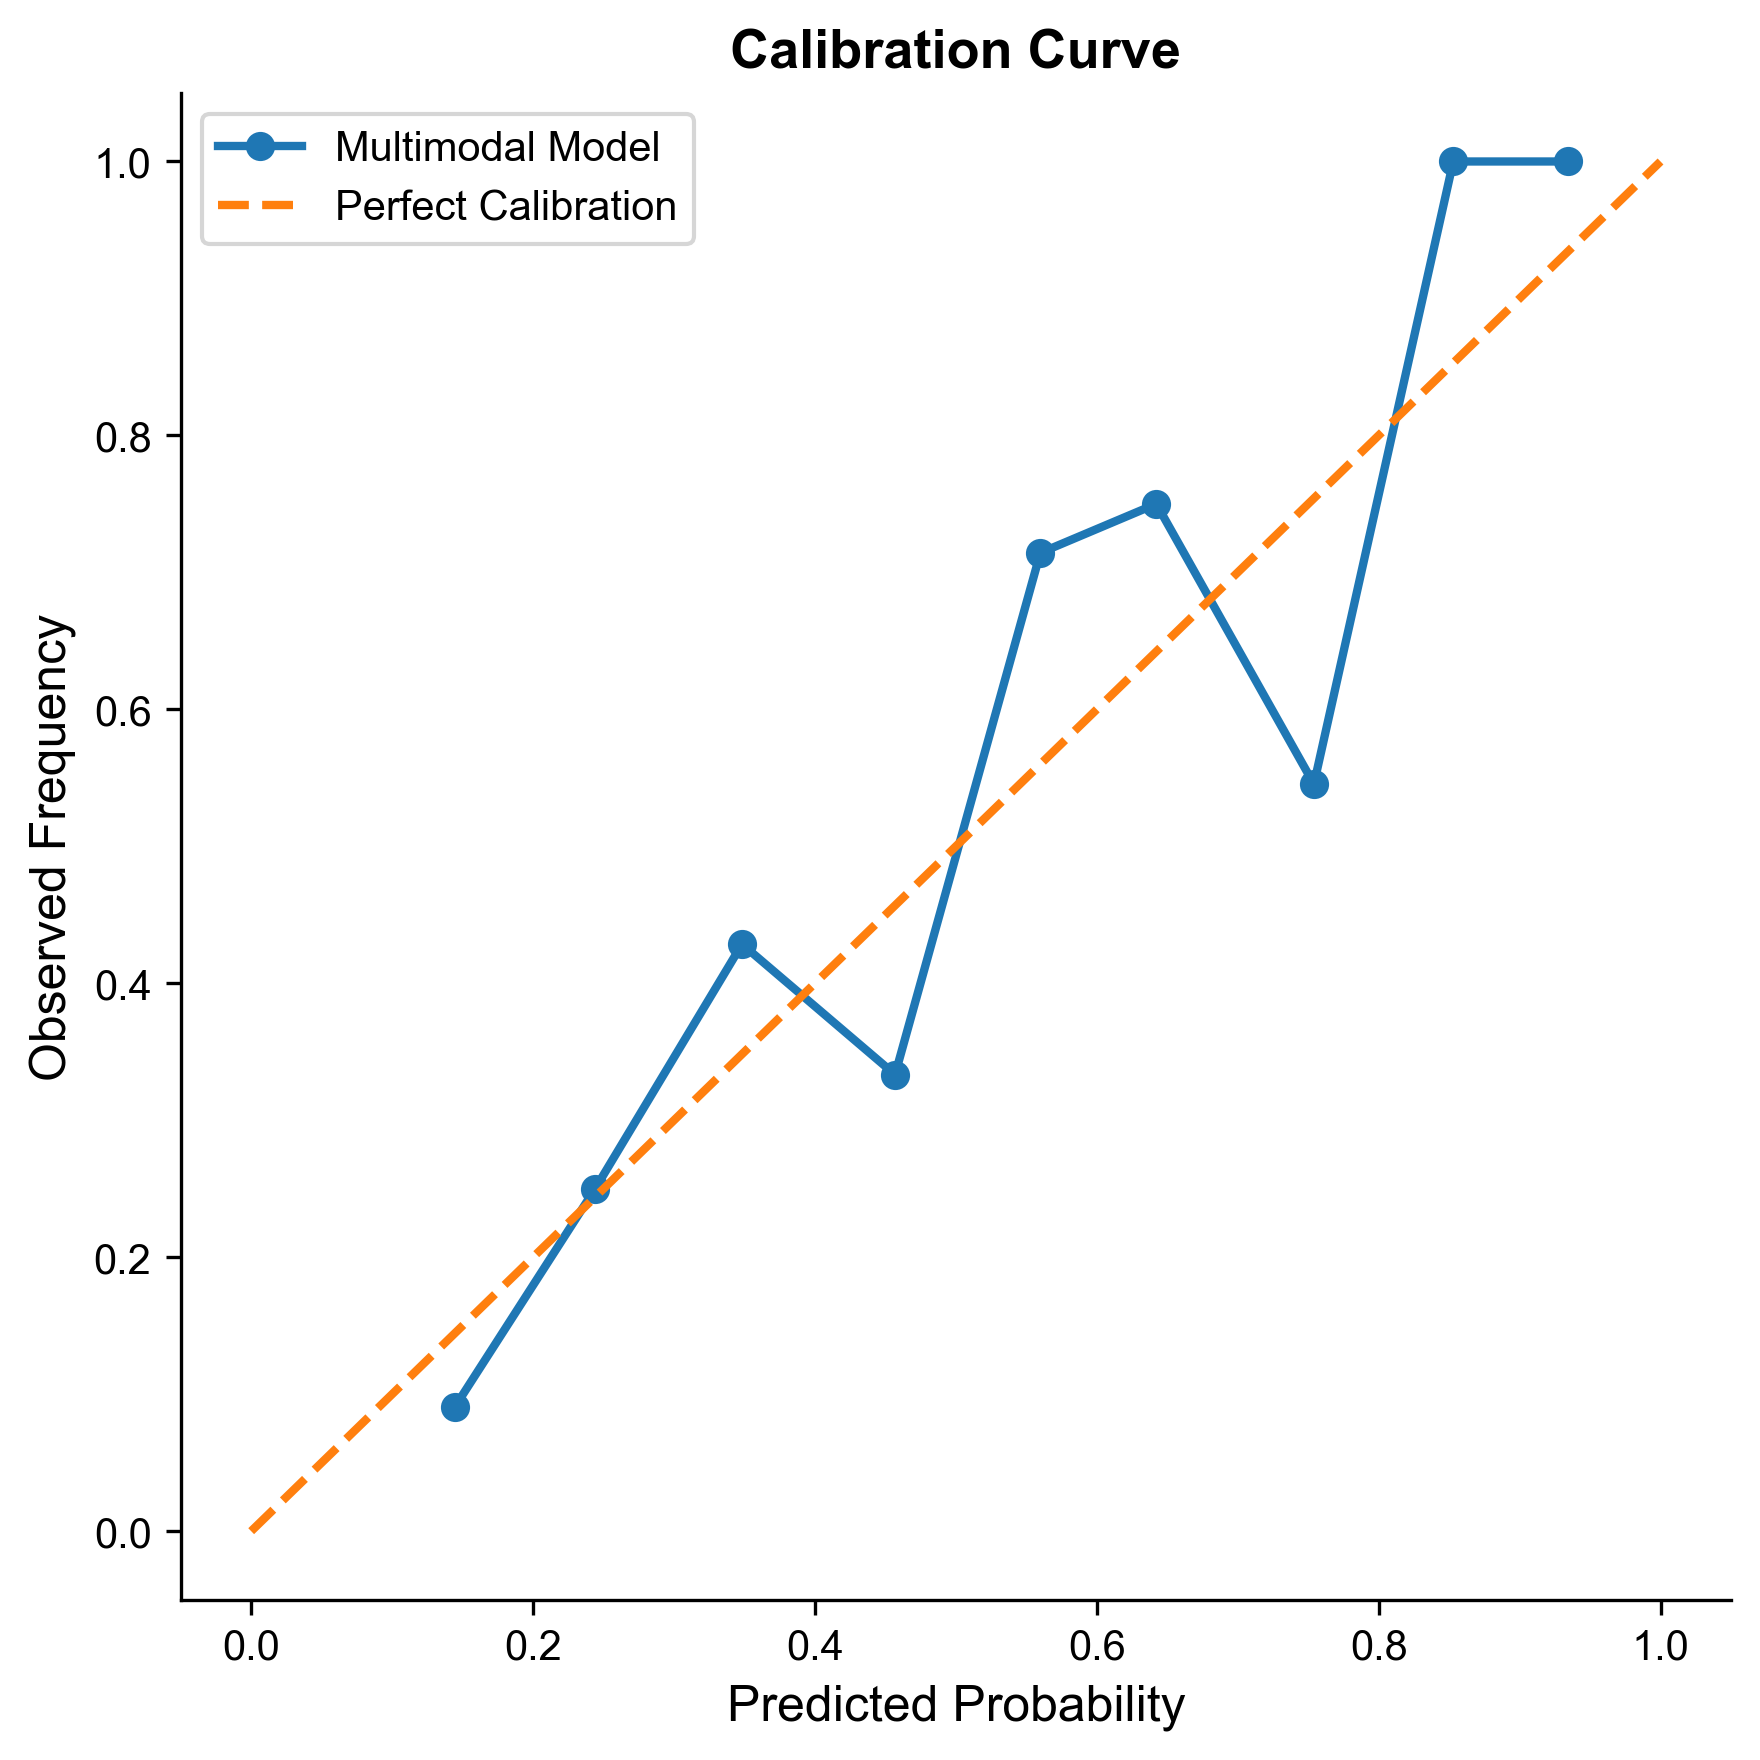

In [72]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    final_probs,
    n_bins=10
)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true,
         marker='o',
         linewidth=2,
         label='Multimodal Model')

plt.plot([0,1],[0,1],
         '--',
         linewidth=2,
         label='Perfect Calibration')

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.savefig("Calibration_Curve.png", dpi=600, bbox_inches='tight')
plt.show()

In [73]:
print(best_params_mid)

{'n_estimators': 207, 'max_depth': 4, 'learning_rate': 0.017837262409571633, 'subsample': 0.7501228335311334, 'colsample_bytree': 0.5814381803414227, 'reg_alpha': 0.0027806129726314814, 'reg_lambda': 0.7803942692014616, 'gamma': 0.49172456974592593}


In [74]:
print(best_clinical_model)

CalibratedClassifierCV(cv=3,
                       estimator=Pipeline(steps=[('prep',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   StandardScaler(),
                                                                                   ['Age',
                                                                                    'BMI',
                                                                                    'Height',
                                                                                    'Weight',
                                                                                    'Alvarado_Score',
                                                                                    'Paedriatic_Appendicitis_Score',
                                                                                    'Body_Temperature',
                             

In [75]:
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5814381803414227, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=0.49172456974592593, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.017837262409571633,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=207, n_jobs=None,
              num_parallel_tree=None, ...)


In [76]:
for var in globals():
    if "auc_scores" in var.lower():
        print(var)

auc_scores


In [77]:
for var in globals():
    if "cv" in var.lower():
        print(var)

CalibratedClassifierCV
cv


In [78]:
import numpy as np

print("Values:", auc_scores)
print("Mean:", np.mean(auc_scores))
print("SD:", np.std(auc_scores))

Values: [0.8596311475409836, 0.9113729508196722, 0.8931782125859333, 0.8508725542041249, 0.8958223162347964]
Mean: 0.882175436277102
SD: 0.023012642852300494
